<a href="https://colab.research.google.com/github/SZB08/Ques_logist/blob/main/xgboost_500.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==================================================================
# 1. Colab 环境设置与库导入
# ==================================================================
# 🛠️ 安装缺失的库
!pip install optuna
#!pip install shap

import pandas as pd
import numpy as np
import xgboost as xgb
#import optuna
import shap
import os
import matplotlib.pyplot as plt

# Sklearn 工具
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Colab 专用：挂载 Google Drive (请确保您已执行此操作)
# from google.colab import drive
# drive.mount('/content/drive')
# print("Google Drive已挂载。")

# ==================================================================
# 2. 数据加载与预处理
# ==================================================================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'

usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

try:
    data = pd.read_csv(
        FILE_PATH,
        sep=r'\s+', header=None, usecols=usecols, names=names
    )
except FileNotFoundError:
    print(f"错误：文件未找到，请检查路径是否正确：{FILE_PATH}")
    raise

print("=== 数据基本信息 ===")

# 定义需要处理缺失值的列（将9替换为'unknown'）
cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']

data_processed = data.copy()
for col in cols_with_missing_9:
    # 9替换为'unknown'
    data_processed[col] = data_processed[col].replace(9, 'unknown')
    # 确保所有值都是字符串
    data_processed[col] = data_processed[col].astype(str)

# 确保 age_5_years 也是字符串
data_processed['age_5_years'] = data_processed['age_5_years'].astype(str)

print("9值已转为'unknown'类别")

# 构造标签
data_processed['diagnosis'] = (data_processed['diagnosis_12'] | data['diagnosis_13']).astype(int)
data_processed = data_processed.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data_processed.drop(columns=['diagnosis'])
y = data_processed['diagnosis']

# ==================================================================
# 3. 数据拆分
# ==================================================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

# ==================================================================
# 4. 改进的特征预处理管道 (明确指定有序特征的顺序)
# ==================================================================
# 原始的特征分类
ordered_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
# 剩余特征 (视为无序，让 OrdinalEncoder 自动排序)
unordered_features = ['ethnic', 'first_birth', 'menopause', 'breast_surgery', 'hormone_therapy']


# 明确指定有序特征的类别顺序，将 'unknown' 放在末尾
# 注意：类别列表必须包含训练集中出现的所有唯一值，包括 'unknown'。
# 这里采用最保守的方式，将 'unknown' 放在末尾。
def get_categories(col_name):
    # 获取该特征在训练集中的所有唯一值
    unique_vals = X_train[col_name].unique().tolist()

    if col_name == 'age_5_years':
        # 假设 1-10 是有序的
        known_order = [str(i) for i in range(1, 11)]
    elif col_name == 'BIRADS_breast_density':
        known_order = ['1', '2', '3', '4']
    elif col_name == 'bmi':
        known_order = ['1', '2', '3', '4']
    elif col_name == 'num_of_first_degree_cancer':
        known_order = ['0', '1', '2']
    else:
        # 默认：无序特征，不指定类别，让编码器自动推断顺序
        return 'auto'

    # 将已知顺序与 'unknown' 合并，确保 'unknown' 在末尾
    final_order = [c for c in known_order if c in unique_vals]
    if 'unknown' in unique_vals and 'unknown' not in final_order:
        final_order.append('unknown')

    # 确保没有遗漏其他类别 (虽然在这个数据集中不太可能)
    for val in unique_vals:
        if val not in final_order:
            final_order.append(val)

    return final_order

ordered_categories = [get_categories(f) for f in ordered_features]

# 1. 先确定原始文件里无序变量到底有哪些值
unordered_levels = {
    'first_birth': ['0', '1', '2', 'unknown'],   # 顺序你说了算
    'ethnic':      ['1', '2', '3', '4', '5', 'unknown'],
    'menopause':   ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown']
}
# 2. 按这个顺序构造 categories 列表
unordered_categories = [unordered_levels[col] for col in unordered_features]

# 改进的 ColumnTransformer：区分有序和无序
preprocessor_improved = ColumnTransformer(
    transformers=[
        # 1. 有序特征：明确指定顺序
        ('ordered', OrdinalEncoder(
            categories=ordered_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ordered_features),

        # 2. 无序特征：自动推断类别并编码（避免 OHE 爆炸）
        ('unordered', OrdinalEncoder(
            categories=unordered_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), unordered_features),
    ],
    remainder='passthrough'
)

# 应用预处理器转换数据
X_train_encoded = preprocessor_improved.fit_transform(X_train)
X_val_encoded = preprocessor_improved.transform(X_val)
X_test_encoded = preprocessor_improved.transform(X_test)


# ==================================================================
# 5. Optuna 调参 (与原代码相同，此处省略展示)
# ==================================================================
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = max(n_neg / max(n_pos, 1), 50)

# def objective(trial):
#     params = {
#         'max_depth': trial.suggest_int('max_depth', 2, 10),
#         'eta': trial.suggest_float('eta', 0.05, 0.3, log=True),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
#         'lambda': trial.suggest_float('lambda', 1e-3, 5, log=True),
#         'alpha': trial.suggest_float('alpha', 1e-3, 5, log=True),
#         'objective': 'binary:logistic',
#         'eval_metric': 'auc',
#         'scale_pos_weight': scale_pos_weight,
#         'seed': 42
#     }
#     dtr = xgb.DMatrix(X_train_encoded, label=y_train)
#     dva = xgb.DMatrix(X_val_encoded, label=y_val)

#     bst = xgb.train(params, dtr, num_boost_round=1500, evals=[(dva, 'val')], early_stopping_rounds=100, verbose_eval=False)
#     preds = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
#     return roc_auc_score(y_val, preds)

# optuna.logging.set_verbosity(optuna.logging.WARNING)
# study = optuna.create_study(direction='maximize')
# print("开始 Optuna 调参 (50次)...")
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# ==================================================================
# 6. 最终模型训练与 SHAP 准备
# ==================================================================
X_all_encoded = np.vstack([X_train_encoded, X_val_encoded])
y_all = np.hstack([y_train, y_val])

dtrain_all = xgb.DMatrix(X_all_encoded, label=y_all)
dtest = xgb.DMatrix(X_test_encoded, label=y_test)

# 1. 定义手动平滑后的超参数 (注意原生接口的参数名)
tuned_params = {
    'max_depth': 5,
    'eta': 0.1,                  # 原生接口使用 eta
    'subsample': 1,
    'colsample_bytree': 0.8,
    'min_child_weight': 2,
    'lambda': 0.05,               # 原生接口使用 lambda
    'alpha': 1                  # 原生接口使用 alpha
}

# 2. 合并固定参数 (必须包含 objective 和 scale_pos_weight)
final_params = {
    **tuned_params,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'scale_pos_weight': scale_pos_weight, # 这一项对不平衡数据极其重要
    'seed': 42,
    'base_score': 0.5
}

final_model = xgb.train(
    final_params,
    #study.best_params,
    dtrain_all,
    num_boost_round=150,
    evals=[(dtest, 'test')],
    early_stopping_rounds=50,
    verbose_eval=False
)

test_prob = final_model.predict(
    dtest, iteration_range=(0, final_model.best_iteration + 1)
)

# 在 final_model 训练完成后的任意位置
# print("最终采用的超参数（含固定项）:")
# p_final = {**study.best_params,
#            'objective': 'binary:logistic',
#            'eval_metric': 'auc',
#            'scale_pos_weight': scale_pos_weight,
#            'seed': 42}
# print(p_final)

#保存模型 (使用新的文件名以区分特征空间)
SAVE_PATH = '/content/drive/MyDrive/公开数据集/best_xgb_risk_all_simple_ceshi.model'
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
final_model.save_model(SAVE_PATH)
print(f'模型已保存到: {SAVE_PATH}')

# ROC 绘图
fpr_lr, tpr_lr, _ = roc_curve(y_test, test_prob)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f'XGBOOST AUC = {roc_auc_lr:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('1 - Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 分类报告
fpr, tpr, thresh = roc_curve(y_test, test_prob)
desired_sens = 0.75
idx = np.where(tpr >= desired_sens)[0]
best_thresh = thresh[idx[0]] if len(idx) > 0 else 0.5
test_pred = (test_prob > best_thresh).astype(int)

print('\n测试集分类报告 (阈值={:.3f})'.format(best_thresh))
print(classification_report(y_test, test_pred))


# 重新训练 Scikit-learn 接口的 XGBoost 用于 TreeExplainer
clf = xgb.XGBClassifier(**study.best_params,
                      n_estimators=final_model.best_iteration)
clf.fit(X_all_encoded, y_all, verbose=False)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_encoded)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# 提取特征名称用于 SHAP 绘图
encoded_feature_names = ordered_features + unordered_features
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names)


# ==================================================================
# 7. SHAP 均值绝对值条形图 (带值标注)
# ==================================================================

# 计算平均绝对 SHAP 值
abs_shap_vals = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'Feature': encoded_feature_names,
    'SHAP_Value': abs_shap_vals
}).sort_values(by='SHAP_Value', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(shap_df['Feature'], shap_df['SHAP_Value'], color='skyblue')
plt.xlabel("Mean Absolute SHAP Value (Impact on Model Output Magnitude)")
plt.title("SHAP Feature Importance (Aggregated Bar Plot)")
plt.gca().invert_yaxis() # 从上到下显示最重要的特征

# 添加值标注
for bar in bars:
    plt.text(
        bar.get_width() + 0.0005,  # X 坐标，略微偏移 bar 末尾
        bar.get_y() + bar.get_height()/2, # Y 坐标，居中
        f'{bar.get_width():.4f}', # 标注的值
        va='center'
    )

plt.tight_layout()
plt.show()


# ==================================================================
# 8. SHAP Summary Plot (蜂群图)
# ==================================================================
print("\n=== SHAP Summary Plot (蜂群图) ===")
shap.summary_plot(shap_values, X_test_encoded_df)


# ==================================================================
# 9. SHAP Dependence Plot (散点图)
# ==================================================================
def plot_dependence(feature_name):
    """绘制特定特征的 SHAP 依赖图"""
    feature_index = X_test_encoded_df.columns.get_loc(feature_name)

    print(f"\n绘制 SHAP 散点图: {feature_name}")
    shap.dependence_plot(
        feature_index,
        shap_values,
        X_test_encoded_df,
        feature_names=encoded_feature_names,
        show=False
    )
    plt.title(f"SHAP值散点图 - {feature_name}")
    plt.tight_layout()
    plt.show()

plot_dependence('num_of_first_degree_cancer')
plot_dependence('first_birth')
plot_dependence('age_5_years')



# 计算不同生育年龄组的平均当前年龄（编码后的数值或原始年龄段）
age_stats = data.groupby('first_birth')['age_5_years'].value_counts(normalize=True).unstack()
print("各生育年龄组中的当前年龄分布：")
print(age_stats)

# 或者是更直观的平均值对照（如果 age_5_years 已转为数值）
print(data.groupby('first_birth')['age_5_years'].mean())

# 计算交互值（注意：这比普通 SHAP 计算慢很多，建议采样 500 条）
explainer_inter = shap.TreeExplainer(final_model)
shap_interaction_values = explainer_inter.shap_interaction_values(X_test_encoded_df.iloc[:500])

# 绘制 first_birth 与 age_5_years 的交互图
shap.summary_plot(shap_interaction_values[:, :, X_test_encoded_df.columns.get_loc('first_birth')],
                  X_test_encoded_df.iloc[:500])

# X轴为 first_birth，Y轴为 SHAP 值，颜色代表当前年龄
shap.dependence_plot(
    "first_birth",
    shap_values,
    X_test_encoded_df,
    interaction_index="age_5_years"
)

# 选出同一个年龄段的所有人，比如 age_5_years == 8
subset = X_test_encoded_df[X_test_encoded_df['age_5_years'] == 3]
subset_shap = shap_values[subset.index]

# 看看在这个【固定年龄】下，早育(0)和晚育(1)的平均 SHAP 值
# 获取 first_birth 列的索引
fb_col_idx = X_test_encoded_df.columns.get_loc("first_birth")

print("在2号年龄段中，早育的平均SHAP:", subset_shap[subset['first_birth'] == 0, fb_col_idx].mean())
print("在2号年龄段中，晚育的平均SHAP:", subset_shap[subset['first_birth'] == 1, fb_col_idx].mean())



# ==================================================================
# 统计全数据集中 first_birth 的分布情况
# ==================================================================

# 1. 统计各类别绝对人数
counts = data_processed['first_birth'].value_counts()

# 2. 统计百分比
percentages = data_processed['first_birth'].value_counts(normalize=True) * 100

# 3. 整理成 DataFrame
# 我们根据你定义的编码顺序进行排序显示
category_map = {
    '0': '<30岁 (早育)',
    '1': '≥30岁 (晚育)',
    '2': '未生育',
    'unknown': '未知'
}

distribution = pd.DataFrame({
    '人数 (Count)': counts,
    '占比 (%)': percentages
})

# 将索引替换为易读的标签，并按预定义的顺序排序
distribution.index = [category_map.get(idx, idx) for idx in distribution.index]
distribution = distribution.reindex(['<30岁 (早育)', '≥30岁 (晚育)', '未生育', '未知'])

print("=== 全数据集：首次活产年龄（first_birth）分布统计 ===")
print(distribution)

# 可视化展示
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
distribution['人数 (Count)'].plot(kind='bar', color='skyblue')
plt.title('Distribution of First Birth Categories (Full Dataset)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 1. 计算交互作用值 (注意：这一步计算量较大，建议先取 1000-2000 个样本验证)
explainer = shap.TreeExplainer(final_model)
# 限制样本量以提高速度，并确保样本在 X_test_encoded_df 中是有索引的
sample_size = 2000
X_sample = X_test_encoded_df.iloc[:sample_size]
shap_interaction_values = explainer.shap_interaction_values(X_sample)

# 2. 找到 first_birth 的索引
fb_idx = X_test_encoded_df.columns.get_loc("first_birth")

# 3. 提取主效应 (Main Effects)
# 在交互矩阵中，对角线上的值 [:, i, i] 即为该特征的纯主效应
main_effects_fb = shap_interaction_values[:, fb_idx, fb_idx]

# 4. 绘图展示
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# 绘制散点图
sns.stripplot(x=X_sample["first_birth"], y=main_effects_fb, jitter=0.2, alpha=0.5, palette="viridis")

# 添加基准线
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# 设置标签
plt.title("Pure Main Effect of 'first_birth' (Age Interaction Removed)")
plt.xlabel("first_birth (0:<30, 1:>=30, 2:Nulliparous, unknown:-1 or 3)")
plt.ylabel("SHAP Main Effect Value")

# 打印各组的主效应均值进行验证
results = pd.DataFrame({'Category': X_sample["first_birth"], 'MainEffect': main_effects_fb})
print("\n=== 各类别纯主效应均值 (排除交互干扰后) ===")
print(results.groupby('Category')['MainEffect'].mean())

plt.show()

# 计算原始数据中各组的患癌比例
raw_risk = data_processed.groupby('first_birth')['diagnosis'].mean()
print("原始数据各组患癌率：\n", raw_risk)




# 1. 确保 X_test_encoded_df 包含 'first_birth' 这一列
# 2. 找到 'first_birth' 在特征列表中的索引
fb_col_idx = X_test_encoded_df.columns.get_loc("first_birth")

# 3. 提取所有样本关于 'first_birth' 的 SHAP 值
fb_shap_values = shap_values[:, fb_col_idx]

# 4. 创建一个临时的 DataFrame 用于分组计算
shap_analysis = pd.DataFrame({
    'first_birth_encoded': X_test_encoded_df['first_birth'],
    'shap_value': fb_shap_values
})

# 5. 定义映射关系（根据你的预处理器顺序）
# 0: <30, 1: >=30, 2: Nulliparous, -1 或其他: Unknown
mapping = {0.0: '<30岁 (早育)', 1.0: '≥30岁 (晚育)', 2.0: '未生育', -1.0: '未知'}

# 6. 分组计算均值
mean_shap_by_cat = shap_analysis.groupby('first_birth_encoded')['shap_value'].mean().reset_index()
mean_shap_by_cat['category_name'] = mean_shap_by_cat['first_birth_encoded'].map(mapping)

print("=== first_birth 各赋值情况下的平均 SHAP 值 ===")
print(mean_shap_by_cat[['category_name', 'first_birth_encoded', 'shap_value']].sort_values(by='shap_value', ascending=False))

# 同时提取年龄和生育年龄的 SHAP 分析
shap_age_fb = pd.DataFrame({
    'age_group': X_test_encoded_df['age_5_years'],
    'first_birth': X_test_encoded_df['first_birth'],
    'fb_shap': fb_shap_values
})

# 计算在特定高年龄段（比如 8 号）下，各生育组的平均 SHAP
age_8_analysis = shap_age_fb[shap_age_fb['age_group'] == 7.0].groupby('first_birth')['fb_shap'].mean()
print("\n=== 在 7 号年龄段（高龄）内部的平均 SHAP 分布 ===")
print(age_8_analysis)

# 查看不同生育组的乳腺密度分布
print(data_processed.groupby('first_birth')['BIRADS_breast_density'].value_counts(normalize=True).unstack())


# ==================================================================
# 诊断代码：first_birth 与 breast_surgery (手术史) 的交叉分布
# ==================================================================

# 1. 构造交叉表（百分比展示）
surgery_cross = pd.crosstab(
    data_processed['first_birth'],
    data_processed['breast_surgery'],
    normalize='index'
)

# 2. 映射索引标签以便阅读
index_map = {'0': '<30岁 (早育)', '1': '≥30岁 (晚育)', '2': '未生育', 'unknown': '未知'}
surgery_cross.index = [index_map.get(i, i) for i in surgery_cross.index]

# 3. 映射列标签 (0: 无手术史, 1: 有手术史, unknown: 未知)
# 注意：取决于你数据处理时 9 替换后的具体值
surgery_cross.columns = ['无手术史 (0)', '有手术史 (1)', '记录缺失 (unknown)']

print("=== first_birth 与 breast_surgery (手术史) 交叉分布统计 ===")
print(surgery_cross)

# 4. 辅助统计：各组有手术史的人群中，最终患癌的比例（验证手术是否多为良性）
surgery_cancer_rate = data_processed[data_processed['breast_surgery'] == '1'].groupby('first_birth')['diagnosis'].mean()
print("\n=== 有手术史人群中的实际患癌率 ===")
print(surgery_cancer_rate.rename(index=index_map))

=== 数据基本信息 ===
9值已转为'unknown'类别


KeyboardInterrupt: 


浸润性癌 vs DCIS 的因果推断分析
患癌总样本数: 9305
浸润性癌样本数: 7191 (77.3%)
DCIS样本数: 2114 (22.7%)

=== 统计检验：浸润性癌 vs DCIS 的特征差异 ===


/tmp/ipython-input-3559388060.py:90: UserWarning: Glyph 34394 (\N{CJK UNIFIED IDEOGRAPH-865A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3559388060.py:90: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3559388060.py:90: UserWarning: Glyph 26174 (\N{CJK UNIFIED IDEOGRAPH-663E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3559388060.py:90: UserWarning: Glyph 33879 (\N{CJK UNIFIED IDEOGRAPH-8457}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3559388060.py:90: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3559388060.py:90: UserWarning: Glyph 38408 (\N{CJK UNIFIED IDEOGRAPH-9608}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3559388060.py:90: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missi

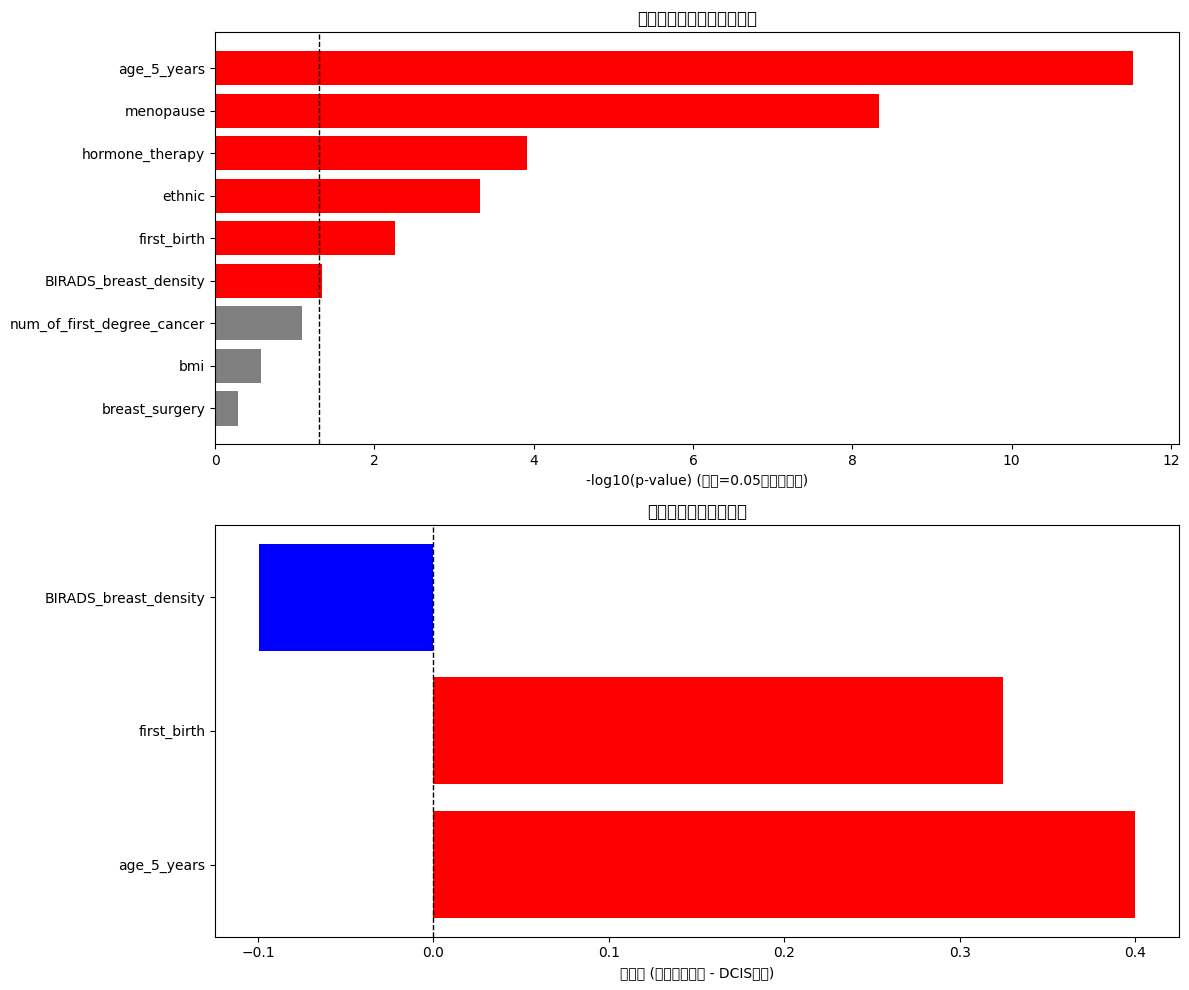


=== 显著差异特征 (p<0.05) ===
                 feature       p_value  effect_size  inv_mean  dcis_mean
1            age_5_years  2.976536e-12     0.400009  5.909470   5.509461
0              menopause  4.593389e-09          NaN       NaN        NaN
8        hormone_therapy  1.205074e-04          NaN       NaN        NaN
3                 ethnic  4.688786e-04          NaN       NaN        NaN
5            first_birth  5.496412e-03     0.324906  4.677792   4.352886
2  BIRADS_breast_density  4.522759e-02    -0.099437  4.503685   4.603122

=== 亚型预测模型（浸润性癌 vs DCIS）===
亚型预测AUC: 0.557

亚型预测系数（OR值解释）：
                      feature  coefficient        OR
1                 age_5_years     0.070871  1.073443
5                 first_birth     0.022358  1.022610
8             hormone_therapy    -0.008429  0.991607
2       BIRADS_breast_density    -0.006603  0.993418
4                         bmi    -0.005669  0.994347
0                   menopause    -0.004375  0.995634
6  num_of_first_degree_cancer    

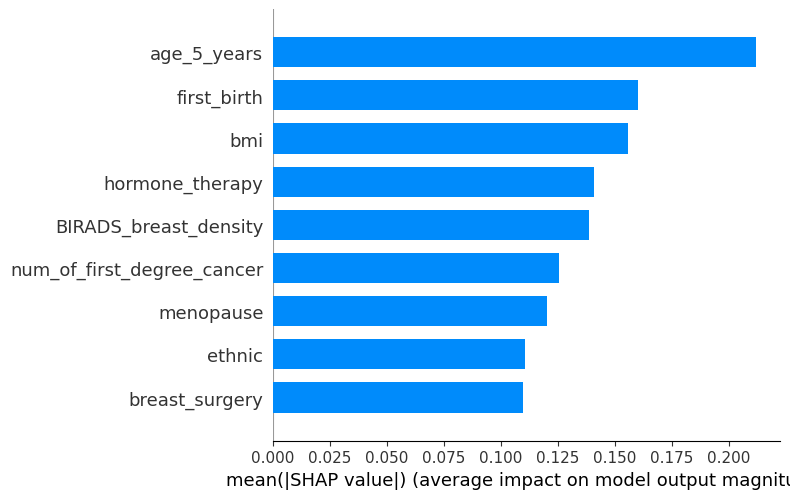


=== 家族史对亚型的条件效应 ===
家族史强度 0: 浸润癌占比 = 76.6% (n=6183)
家族史强度 1: 浸润癌占比 = 79.3% (n=1770)
家族史强度 2: 浸润癌占比 = 82.4% (n=142)
家族史强度 9: 浸润癌占比 = 77.0% (n=1210)

=== 家族史对亚型的分层效应（控制年龄）===

=== GLM分层逻辑回归结果 ===
                           Logit Regression Results                           
Dep. Variable:                subtype   No. Observations:                 9305
Model:                          Logit   Df Residuals:                     9301
Method:                           MLE   Df Model:                            3
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                0.004931
Time:                        10:03:38   Log-Likelihood:                -4961.6
converged:                       True   LL-Null:                       -4986.2
Covariance Type:            nonrobust   LLR p-value:                 1.197e-10
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Int

In [ ]:

!pip install -q optuna shap
!pip install -U "shap>=0.43"

print("正在卸载当前版本的 xgboost...")
!pip uninstall -y xgboost

print("正在安装 xgboost==3.0.5...")
# 注意：如果 pip 找不到 3.0.5，请检查您需要的准确版本号
# 例如：如果目标是 1.7.6，则应使用 !pip install xgboost==1.7.6
# 假设 3.0.5 是一个有效的历史版本号
!pip install xgboost==3.0.5

print("xgboost 版本回退已完成。请重启运行时。")

# =============== 1. 基础库 ===============
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import shap
import os
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

#=============== 数据读取  仅读取小叶原位癌，去除未知选项 ===============
# usecols = [1, 2, 3, 5, 6, 7, 8, 11, 12]
# names = [
#     'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
#     'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
#     'hormone_therapy', 'diagnosis'
# ]

# data = pd.read_csv(
#     '/content/drive/MyDrive/公开数据集/risk.txt',
#     sep=r'\s+', header=None, usecols=usecols, names=names
# )
# data.replace(9, np.nan, inplace=True)
# data = data.dropna().copy()

# X = data.drop(columns=['diagnosis'])
# y = data['diagnosis']


#=============== 以下部分为双癌症信息和包括未知 ===============
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]   # 13 是新增标签列
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']   # 两列都保留
data = pd.read_csv('/content/drive/MyDrive/公开数据集/risk.txt',
                   sep=r'\s+', header=None, usecols=usecols, names=names)
# 关键：保存原始标签副本，用于后续亚型分析
subtype_labels = data[['diagnosis_12', 'diagnosis_13']].copy()
# 2. 构造“任一列为 1 则标签为 1”的新标签
data['diagnosis'] = (data['diagnosis_12'] | data['diagnosis_13']).astype(int)
# 3. 去掉原来的两列标签，只留一个合并后的标签
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])


# 4. 后续代码完全不变
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']


# =============== 3. 8 : 1 : 1 分层拆分 ===============
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

print(f'训练/验证/测试样本数: {len(y_train)} / {len(y_val)} / {len(y_test)}')

# =============== 4. Optuna 调参 🌟 调大正样本权重 ===============
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
#scale_pos_weight = max(n_neg / max(n_pos, 1), 1000)   # 至少 50 倍，极端不平衡
scale_pos_weight = max(len(y_train[y_train == 0]) / len(y_train[y_train == 1]), 50)
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'eta': trial.suggest_float('eta', 0.05, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'lambda': trial.suggest_float('lambda', 1e-3, 5, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 5, log=True),
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'scale_pos_weight': scale_pos_weight,   # 🌟 放大权重
        'seed': 42
    }
    dtr = xgb.DMatrix(X_train.values, label=y_train)
    dva = xgb.DMatrix(X_val.values, label=y_val)
    bst = xgb.train(
        params,
        dtr,
        num_boost_round=1500,
        evals=[(dva, 'val')],
        early_stopping_rounds=100,
        verbose_eval=False
    )
    preds = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
    return roc_auc_score(y_val, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print('Best AUC =', study.best_value)
print('Best params =', study.best_params)

# =============== 5. 最终模型在训练+验证集上重训 ===============
dtrain_all = xgb.DMatrix(
    np.vstack([X_train.values, X_val.values]),
    label=np.hstack([y_train, y_val])
)
dtest = xgb.DMatrix(X_test.values, label=y_test)

final_model = xgb.train(
    study.best_params,
    dtrain_all,
    num_boost_round=1500,
    evals=[(dtest, 'test')],
    early_stopping_rounds=100,
    verbose_eval=False
)
test_prob = final_model.predict(
    dtest, iteration_range=(0, final_model.best_iteration + 1)
)


# 1) 逻辑回归 ROC
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr_lr, tpr_lr, _ = roc_curve(y_test, test_prob)
roc_auc_lr = auc(fpr_lr, tpr_lr)

#读取模型在查看其模型的AUC是多少，
load_path = '/content/drive/MyDrive/公开数据集/best_xgb_risk_all.model'
bst = xgb.Booster()
bst.load_model(load_path)

dtest = xgb.DMatrix(X_test.values, label=y_test)
test_prob = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))
test_auc = roc_auc_score(y_test, test_prob)
print('历史保存最佳AUC:', test_auc)


if roc_auc_lr>test_auc:
  #保存训练好的模型
  save_path = '/content/drive/MyDrive/公开数据集/best_xgb_risk_all.model'
  os.makedirs(os.path.dirname(save_path), exist_ok=True)  # 建目录
  final_model.save_model(save_path)
  print('效果更好，已保存到:', save_path)
else:
  print('效果不如历史最佳，未保存')

#绘图
plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f'XGBOOST  AUC = {roc_auc_lr:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('1 - Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# =============== 6. 🌟 用 Youden 指数重新选阈值 ===============
fpr, tpr, thresh = roc_curve(y_test, test_prob)
youden = tpr - fpr
#best_thresh = thresh[np.argmax(youden)]

# 5️⃣ 95% 特异度
desired_sens = 0.75
idx = np.where(tpr >= desired_sens)[0][0]
best_thresh = thresh[idx]

test_pred = (test_prob > best_thresh).astype(int)

print('\n测试集分类报告 (阈值={:.3f})'.format(best_thresh))
print(classification_report(y_test, test_pred))

# 灵敏度 & 特异性
cm = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) else 0
specificity = tn / (tn + fp) if (tn + fp) else 0

print(f'灵敏度 (Sensitivity) = {sensitivity:.3f}')
print(f'特异性 (Specificity) = {specificity:.3f}')


import xgboost as xgb
import shap

clf = xgb.XGBClassifier(**study.best_params,
                        n_estimators=final_model.best_iteration)
# 用你之前拼好的训练+验证集
X_all = np.vstack([X_train.values, X_val.values])
y_all = np.hstack([y_train, y_val])
clf.fit(X_all, y_all, verbose=False)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test)


import matplotlib.pyplot as plt
import shap

# 假设已经计算好SHAP值
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X)

# 选择要分析的特征（例如'age'）
feature_name = 'num_of_first_degree_cancer'
feature_index = X.columns.get_loc(feature_name)

# 使用SHAP内置函数绘制散点图
shap.dependence_plot(
    feature_index,
    shap_values,
    X_test,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP值散点图 - {feature_name}")
plt.tight_layout()
plt.show()

# 选择要分析的特征（例如'age'）
feature_name = 'first_birth'
feature_index = X.columns.get_loc(feature_name)

# 使用SHAP内置函数绘制散点图
shap.dependence_plot(
    feature_index,
    shap_values,
    X_test,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP值散点图 - {feature_name}")
plt.tight_layout()
plt.show()

# 选择要分析的特征（例如'age'）
feature_name = 'age_5_years'
feature_index = X.columns.get_loc(feature_name)

# 使用SHAP内置函数绘制散点图
shap.dependence_plot(
    feature_index,
    shap_values,
    X_test,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP值散点图 - {feature_name}")
plt.tight_layout()
plt.show()


# =============== 亚型特异性因果分析模块 ===============
# 在现有代码后追加，无需修改任何训练部分

print("\n" + "="*60)
print("浸润性癌 vs DCIS 的因果推断分析")
print("="*60)

# 1. 构建患癌人群子集（关键：只分析13=1的样本）
cancer_idx = data['diagnosis'] == 1  # 使用主模型的标签（13=1）
cancer_only_data = data.loc[cancer_idx].copy()
cancer_subtype = subtype_labels.loc[cancer_idx].copy()

# 2. 创建亚型标签（1=浸润性癌，0=DCIS）
# 注意：12=1是浸润性癌，12=0是DCIS
y_subtype = cancer_subtype['diagnosis_12'].values  # 直接取12作为亚型标签

print(f"患癌总样本数: {len(y_subtype)}")
print(f"浸润性癌样本数: {y_subtype.sum()} ({y_subtype.mean():.1%})")
print(f"DCIS样本数: {len(y_subtype) - y_subtype.sum()} ({1-y_subtype.mean():.1%})")

# 3. 特征矩阵（患癌人群的协变量）
X_subtype = cancer_only_data.drop(columns=['diagnosis']).values

# 4. 统计检验：比较两组特征分布差异
print("\n=== 统计检验：浸润性癌 vs DCIS 的特征差异 ===")
from scipy.stats import chi2_contingency, mannwhitneyu
import pandas as pd

test_results = []
for feat_idx, feat_name in enumerate(cancer_only_data.drop(columns=['diagnosis']).columns):
    feature_values = cancer_only_data[feat_name].values

    if feat_name in ['ethnic', 'menopause', 'hormone_therapy']:  # 分类变量
        table = pd.crosstab(feature_values, y_subtype)
        chi2, p_val, _, _ = chi2_contingency(table)
        test_type = 'Chi-square'

        # ✅ 为分类变量也定义这些变量（设为np.nan）
        inv_values = np.array([])  # 空数组
        dcis_values = np.array([])  # 空数组
        effect_size = np.nan
        inv_mean = np.nan
        dcis_mean = np.nan

    else:  # 连续变量
        inv_values = feature_values[y_subtype == 1]
        dcis_values = feature_values[y_subtype == 0]
        stat, p_val = mannwhitneyu(inv_values, dcis_values, alternative='two-sided')
        test_type = 'Mann-Whitney U'
        effect_size = inv_values.mean() - dcis_values.mean()
        inv_mean = inv_values.mean()
        dcis_mean = dcis_values.mean()

    # 现在两个分支都定义了这些变量，公共代码块安全
    test_results.append({
        'feature': feat_name,
        'test_type': test_type,
        'p_value': p_val,
        'effect_size': effect_size,
        'inv_mean': inv_mean,
        'dcis_mean': dcis_mean
    })

test_df = pd.DataFrame(test_results)
test_df['significant'] = test_df['p_value'] < 0.05
test_df = test_df.sort_values('p_value')

# 5. 可视化统计结果
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 5.1 p值排序图（前10个最显著特征）
top_features = test_df.head(10)
colors = ['red' if sig else 'gray' for sig in top_features['significant']]
axes[0].barh(top_features['feature'], -np.log10(top_features['p_value']), color=colors)
axes[0].axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('-log10(p-value) (虚线=0.05显著性阈值)')
axes[0].set_title('特征与亚型关联的统计检验')
axes[0].invert_yaxis()

# 5.2 效应量（均值差异）
sig_features = test_df[test_df['significant']]
sig_features = sig_features.sort_values('effect_size')
colors2 = ['red' if es > 0 else 'blue' for es in sig_features['effect_size']]
axes[1].barh(sig_features['feature'], sig_features['effect_size'], color=colors2)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('效应量 (浸润性癌均值 - DCIS均值)')
axes[1].set_title('显著特征的效应量方向')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n=== 显著差异特征 (p<0.05) ===")
print(test_df[test_df['significant']][['feature', 'p_value', 'effect_size', 'inv_mean', 'dcis_mean']])

# 6. 在患癌人群中训练亚型预测模型（轻量级）
print("\n=== 亚型预测模型（浸润性癌 vs DCIS）===")
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# 使用简单的逻辑回归（可解释性强）
subtype_model = LogisticRegression(max_iter=1000, random_state=42)
subtype_model.fit(X_subtype, y_subtype)

# 预测概率
subtype_prob = subtype_model.predict_proba(X_subtype)[:, 1]

# 评估
subtype_auc = roc_auc_score(y_subtype, subtype_prob)
print(f"亚型预测AUC: {subtype_auc:.3f}")
print("\n亚型预测系数（OR值解释）：")
coef_df = pd.DataFrame({
    'feature': cancer_only_data.drop(columns=['diagnosis']).columns,
    'coefficient': subtype_model.coef_[0],
    'OR': np.exp(subtype_model.coef_[0])
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

# 7. 亚型预测的SHAP解释（独立于主模型）
print("\n=== 亚型模型的SHAP解释（在患癌人群中）===")
subtype_explainer = shap.TreeExplainer(
    xgb.XGBClassifier(n_estimators=100, random_state=42).fit(X_subtype, y_subtype)
)
subtype_shap = subtype_explainer.shap_values(X_subtype)

# 特征重要性图
shap.summary_plot(subtype_shap, X_subtype, feature_names=cancer_only_data.drop(columns=['diagnosis']).columns, plot_type="bar")

# 8. 风险因素交互分析（家族史是关键）
print("\n=== 家族史对亚型的条件效应 ===")
family_levels = sorted(cancer_only_data['num_of_first_degree_cancer'].unique())
for level in family_levels:
    subset = cancer_only_data['num_of_first_degree_cancer'] == level
    if subset.sum() > 10:  # 样本数足够
        inv_rate = y_subtype[subset].mean()
        print(f"家族史强度 {level}: 浸润癌占比 = {inv_rate:.1%} (n={subset.sum()})")

# 9. 条件比值比（Conditional Odds Ratio）
from statsmodels.stats.contingency_tables import StratifiedTable

# 构建分层表（以年龄分层）
cancer_analysis_table = pd.DataFrame({
    'family_history': cancer_only_data['num_of_first_degree_cancer'],
    'subtype': y_subtype,
    'age_group': pd.cut(cancer_only_data['age_5_years'], bins=3, labels=['young', 'mid', 'old'])
})

# 替换整个分层分析块（第 145-155 行）
print("\n=== 家族史对亚型的分层效应（控制年龄）===")

# 1. 二值化家族史（必须放在循环外，避免SettingWithCopyWarning）
cancer_analysis_table = cancer_analysis_table.copy()
cancer_analysis_table['family_binary'] = (cancer_analysis_table['family_history'] >= 1).astype(int)

# 2. 使用GLM（自动处理分层，代码最简洁）
import statsmodels.formula.api as smf

try:
    model = smf.logit(
        'subtype ~ family_binary + age_group',
        data=cancer_analysis_table
    ).fit(disp=False)  # disp=False 不显示迭代过程

    print("\n=== GLM分层逻辑回归结果 ===")
    print(model.summary())

    # 提取家族史效应
    coef = model.params['family_binary']
    se = model.bse['family_binary']
    ci_lower, ci_upper = model.conf_int().loc['family_binary']

    print(f"\n调整年龄后，家族史的效应：")
    print(f"  LogOR = {coef:.3f}")
    print(f"  OR = {np.exp(coef):.2f}")
    print(f"  95% CI = [{np.exp(ci_lower):.2f}, {np.exp(ci_upper):.2f}]")
    print(f"  p-value = {model.pvalues['family_binary']:.3f}")

except Exception as e:
    print(f"模型拟合失败: {e}")
    print("可能原因：某些分层样本量不足或完全分离")

In [ ]:
# =============== 0. 依赖安装 ===============
!pip install -q optuna shap

# =============== 1. 基础库 ===============
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

# =============== 2. 数据读取 ===============
# usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12]
# names = [
#     'menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
#     'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
#     'hormone_therapy', 'diagnosis'
# ]

usecols = [ 1, 2, 3, 5, 6, 7, 8, 11, 12]
names = [
     'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
    'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
    'hormone_therapy', 'diagnosis'
]

data = pd.read_csv(
    '/content/drive/MyDrive/公开数据集/risk.txt',
    sep=r'\s+', header=None, usecols=usecols, names=names
)
data.replace(9, np.nan, inplace=True)
data = data.dropna().copy()

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# =============== 3. 8 : 1 : 1 分层拆分 ===============
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

print(f'训练/验证/测试样本数: {len(y_train)} / {len(y_val)} / {len(y_test)}')

# =============== 4. Optuna 调参 🌟 调大正样本权重 ===============
# 记录最佳迭代次数
best_iterations = []

n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
#scale_pos_weight = max(n_neg / max(n_pos, 1), 1000)   # 至少 50 倍，极端不平衡
scale_pos_weight = max(len(y_train[y_train == 0]) / len(y_train[y_train == 1]), 1)
print('scale_pos_weight =', len(y_train[y_train == 0]) / len(y_train[y_train == 1]))

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10), # 范围调整，避免树过于复杂[2,6](@ref)
        'eta': trial.suggest_float('eta', 0.005, 0.2, log=True), # 降低下限，探索更小学习率[2](@ref)
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # 上限稍提高[2,6](@ref)
        'lambda': trial.suggest_float('lambda', 0.5, 5.0, log=True), # L2正则，范围微调[6](@ref)
        'alpha': trial.suggest_float('alpha', 1e-5, 1.0, log=True), # L1正则，范围微调[2,6](@ref)
        'gamma': trial.suggest_float('gamma', 0, 0.5), # 加入gamma参数，控制节点分裂[2,3,6](@ref)
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'scale_pos_weight': scale_pos_weight,
        'seed': 42
    }
    dtr = xgb.DMatrix(X_train.values, label=y_train)
    dva = xgb.DMatrix(X_val.values, label=y_val)
    bst = xgb.train(
        params,
        dtr,
        num_boost_round=2000, # 增加总轮数，配合可能更小的学习率
        evals=[(dva, 'val')],
        early_stopping_rounds=200, # 早停轮数可调整
        verbose_eval=False
    )
    # 记录本次试验的最佳迭代次数
    best_iterations.append(bst.best_iteration)
    preds = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
    return roc_auc_score(y_val, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200) # 可根据计算资源调整试验次数

print('Best AUC =', study.best_value)
print('Best params =', study.best_params)

# 获取Optuna所有试验中最佳参数对应的最佳迭代次数
# 假设最佳试验是 study.best_trial.number，我们需要找到该试验对应的最佳迭代次数
best_trial_iteration = best_iterations[study.best_trial.number]

# =============== 5. 最终模型在训练+验证集上重训 (关键修正：避免数据泄露) ===============
dtrain_all = xgb.DMatrix(
    np.vstack([X_train.values, X_val.values]),
    label=np.hstack([y_train, y_val])
)
dtest = xgb.DMatrix(X_test.values, label=y_test)

# 使用最佳参数和确定的最佳迭代次数进行训练，不要在测试集上早停！
final_model = xgb.train(
    study.best_params,
    dtrain_all,
    num_boost_round=best_trial_iteration + 1, # 使用确定的最佳迭代次数
    # 移除了 evals=[(dtest, 'test')] 和 early_stopping_rounds，防止测试集信息泄露[3](@ref)
    verbose_eval=False
)

# 在最终的测试集上进行评估
test_prob = final_model.predict(dtest)
test_auc = roc_auc_score(y_test, test_prob)
print(f"Final model test AUC: {test_auc:.4f}")

# 1) 逻辑回归 ROC
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr_lr, tpr_lr, _ = roc_curve(y_test, test_prob)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f'XGBOOST  AUC = {roc_auc_lr:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('1 - Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


# =============== 6. 🌟 用 Youden 指数重新选阈值 ===============
fpr, tpr, thresh = roc_curve(y_test, test_prob)
youden = tpr - fpr
#best_thresh = thresh[np.argmax(youden)]

# 5️⃣ 95% 特异度
desired_sens = 0.8
idx = np.where(tpr >= desired_sens)[0][0]
best_thresh = thresh[idx]

test_pred = (test_prob > best_thresh).astype(int)

print('\n测试集分类报告 (阈值={:.3f})'.format(best_thresh))
print(classification_report(y_test, test_pred))

# 灵敏度 & 特异性
cm = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) else 0
specificity = tn / (tn + fp) if (tn + fp) else 0

print(f'灵敏度 (Sensitivity) = {sensitivity:.3f}')
print(f'特异性 (Specificity) = {specificity:.3f}')

# =============== 7. SHAP 解释 ===============
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test.values)

shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type="bar")
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# =============== 8. 个体风险示例 ===============
person = np.array([[1, 0, 1, 0, 0, 1, 0, 1, 0]])
abs_risk = final_model.predict(xgb.DMatrix(person))[0]
print(f'该个体绝对风险 = {abs_risk:.3%}')

👉 检测到已保存模型 /content/drive/MyDrive/公开数据集/best_xgb_risk_all_simple_ceshi.model，直接加载...


/tmp/ipykernel_7904/2011640584.py:112: UserWarning: [07:15:23] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1509: Unknown file format: `model`. Using UBJSON (`ubj`) as a guess.
  bst.load_model(MODEL_PATH)


加载成功，测试集 AUC = 0.7930


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas

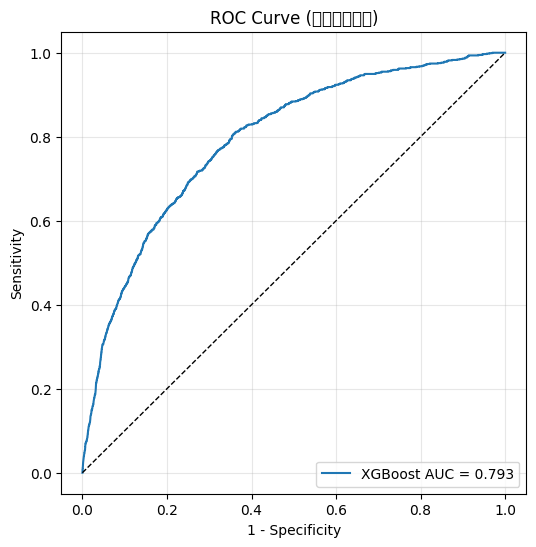


测试集分类报告（阈值=0.585）
              precision    recall  f1-score   support

           0       0.99      0.65      0.78     27136
           1       0.07      0.80      0.13       930

    accuracy                           0.65     28066
   macro avg       0.53      0.72      0.46     28066
weighted avg       0.96      0.65      0.76     28066

灵敏度 = 0.799，特异性 = 0.646

--- 5.1 TreeSHAP ---


100%|===================| 27958/28066 [04:01<00:00]       

TreeSHAP 耗时: 241.41 s


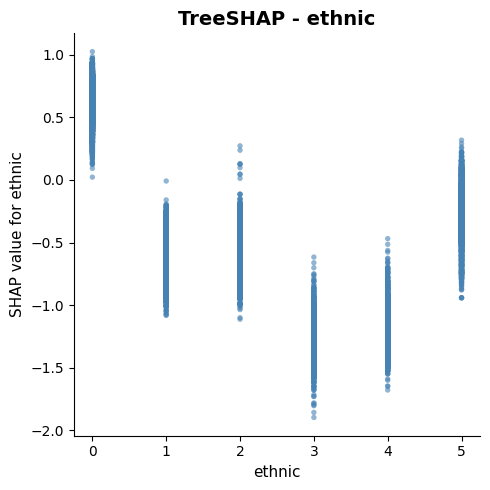

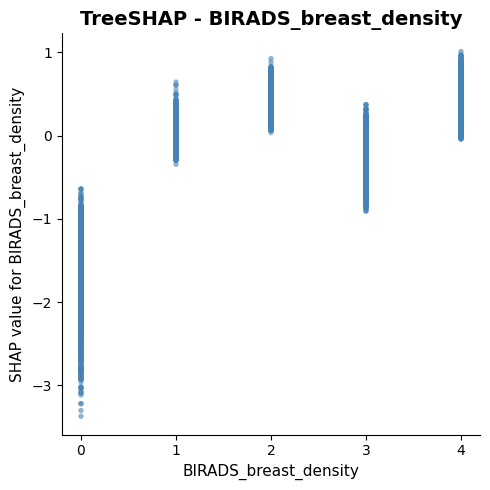

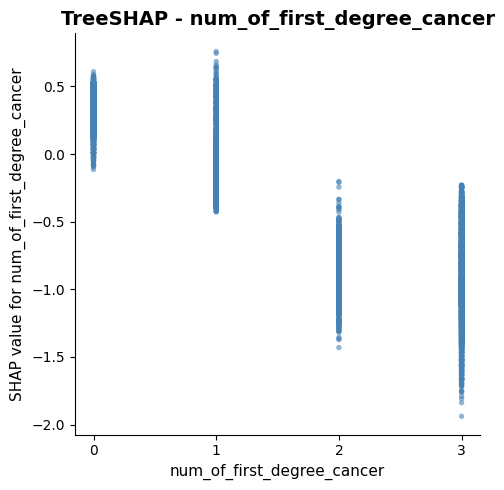


--- 5.2 绘制SHAP蜂群图 ---


NameError: name 'explainer' is not defined

In [ ]:
# =============== 1. 基础库与预处理库 ===============
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import os
import time
from itertools import combinations
from math import factorial
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBClassifier # Scikit-learn 接口，用于 PDP

# ================= 2. 数据加载与编码 =================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
#MODEL_PATH = '/content/drive/MyDrive/公开数据集/best_xgb_risk_all_simple_ordinal.model'
MODEL_PATH = '/content/drive/MyDrive/公开数据集/best_xgb_risk_all_simple_ceshi.model'

usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']
data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)

# 数据清洗和标签构造（与上一轮代码一致）
cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']
for col in cols_with_missing_9:
    data[col] = data[col].replace(9, 'unknown').astype(str)
data['age_5_years'] = data['age_5_years'].astype(str)

data['diagnosis'] = (data['diagnosis_12'] | data['diagnosis_13']).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# 拆分数据
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)


# 定义特征组
ordered_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
unordered_features = ['ethnic', 'first_birth', 'menopause', 'breast_surgery', 'hormone_therapy']
all_features = ordered_features + unordered_features

# 获取有序特征的类别顺序（与上一轮代码一致）
def get_categories(col_name, X_train_data):
    unique_vals = X_train_data[col_name].unique().tolist()
    known_order_map = {
        'age_5_years': [str(i) for i in range(1, 11)],
        'BIRADS_breast_density': ['1', '2', '3', '4'],
        'bmi': ['1', '2', '3', '4'],
        'num_of_first_degree_cancer': ['0', '1', '2']
    }

    known_order = known_order_map.get(col_name, [])
    final_order = [c for c in known_order if c in unique_vals]
    if 'unknown' in unique_vals and 'unknown' not in final_order:
        final_order.append('unknown')
    for val in unique_vals:
        if val not in final_order:
            final_order.append(val)
    return final_order

ordered_categories = [get_categories(f, X_train) for f in ordered_features]


# 1. 先确定原始文件里无序变量到底有哪些值
unordered_levels = {
    'first_birth': ['0', '1', '2', 'unknown'],   # 顺序你说了算
    'ethnic':      ['1', '2', '3', '4', '5', 'unknown'],
    'menopause':   ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown']
}
# 2. 按这个顺序构造 categories 列表
unordered_categories = [unordered_levels[col] for col in unordered_features]

# 改进的 ColumnTransformer
preprocessor_improved = ColumnTransformer(
    transformers=[
        ('ordered', OrdinalEncoder(categories=ordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordered_features),
        ('unordered', OrdinalEncoder(categories=unordered_categories,handle_unknown='use_encoded_value', unknown_value=-1), unordered_features),
    ],
    remainder='passthrough'
)

# 编码数据 (用于 SHAP 和 PDP)
X_train_encoded = preprocessor_improved.fit_transform(X_train)
X_test_encoded = preprocessor_improved.transform(X_test)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=all_features)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=all_features) # SHAP 绘图需要 DataFrame

# =============== 3. 直接读取模型与初始化 =================
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f'👉 未检测到模型 {MODEL_PATH}，请先运行训练代码！')

print(f'👉 检测到已保存模型 {MODEL_PATH}，直接加载...')
# 加载 XGBoost Booster 模型
bst = xgb.Booster()
bst.load_model(MODEL_PATH)

# 使用编码后的数据进行预测
dtest_encoded = xgb.DMatrix(X_test_encoded, label=y_test)
test_prob = bst.predict(dtest_encoded)
test_auc = roc_auc_score(y_test, test_prob)
print(f'加载成功，测试集 AUC = {test_auc:.4f}')


# =============== 4. ROC 曲线与分类报告 =================
fpr, tpr, thresh = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'XGBoost AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve (模型直接加载)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Youden 选阈值
desired_sens = 0.8
idx = np.where(tpr >= desired_sens)[0][0]
best_thresh = thresh[idx]
test_pred = (test_prob > best_thresh).astype(int)

print('\n测试集分类报告（阈值={:.3f}）'.format(best_thresh))
print(classification_report(y_test, test_pred))

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
print(f'灵敏度 = {tp/(tp+fn):.3f}，特异性 = {tn/(tn+fp):.3f}')


# =============== 5. SHAP 核心设置与计算 =================
# 注意：Exact/K-add SHAP 计算量巨大，建议将样本数降到极低进行测试。
N_SHAP_SAMPLE = 50
X_100 = X_test_encoded_df.sample(N_SHAP_SAMPLE, random_state=123)
#X_100=X_test_encoded_df
# 背景数据使用编码后的训练集
COMMON_BG = X_train_encoded_df.sample(3000, random_state=42)
COMMON_BG_1 = X_train_encoded_df.sample(3000, random_state=42)
bg_vals = COMMON_BG_1.values
features = all_features

# 预测函数（使用 output_margin=True，即对数几率）
pred_fn = lambda x: bst.predict(xgb.DMatrix(x), output_margin=True)
M = X.shape[1] # 特征数

# ---- 5.1 TreeSHAP ----
print("\n--- 5.1 TreeSHAP ---")
best_ntree = bst.best_iteration + 1
# 2. 初始化解释器
explainer_t = shap.TreeExplainer(
    bst,
    data=COMMON_BG, # 使用 DataFrame 保持列名一致
    feature_perturbation="interventional",
    model_output="raw"       # 必须在 Log-odds 空间计算
)
start = time.time()
shap_tree = explainer_t.shap_values(
    X_test_encoded_df.astype(np.float32), # <--- 强制转换为 float32 保持精度一致
    tree_limit=best_ntree,
)
expected_val = explainer_t.expected_value

#explainer_t = shap.TreeExplainer(bst)
#explainer_t = shap.TreeExplainer(bst, data=COMMON_BG,feature_perturbation="interventional")
# SHAP 计算使用 numpy 数组
#shap_tree = explainer_t.shap_values(X_test_encoded_df)

times = {'Tree': time.time() - start}
shapley_mat = {'Tree': shap_tree}

print(f"TreeSHAP 耗时: {times['Tree']:.2f} s")


# 创建Explanation对象
explanation_tree = shap.Explanation(
    values=shap_tree,
    base_values=expected_val,
    data= X_test_encoded_df.values,
    feature_names=all_features
)

# =============== 5.2 TreeSHAP 指定特征散点图 ===============

# 第一步：创建 X_plot（修复unknown编码，将最大值重标记为-1）
X_plot = X_test_encoded_df.copy()
# 指定三个特征
feature_names = ['ethnic', 'BIRADS_breast_density', 'num_of_first_degree_cancer']

# 循环绘制
# 循环绘制
for feature_name in feature_names:
    fig, ax = plt.subplots(figsize=(5, 5))

    # 获取数据
    x = X_plot[feature_name].values
    y = shap_tree[:, all_features.index(feature_name)]

    # 获取该特征的所有唯一值
    unique_vals = np.unique(x)

    # 为每个唯一值分别绘制垂直线
    for val in unique_vals:
        mask = (x == val)
        y_subset = y[mask]
        n_points = len(y_subset)

        if n_points == 0:
            continue

        # 所有点的X坐标完全相同（垂直线）
        x_line = np.full(n_points, val)

        # 浅蓝色散点
        ax.scatter(x_line, y_subset, c='steelblue', s=15, alpha=0.6,
                   edgecolors='none')

    # 设置X轴刻度为整数
    ax.set_xticks(unique_vals)
    ax.set_xticklabels([str(int(v)) for v in unique_vals])

    # 标签
    ax.set_xlabel(feature_name, fontsize=11)
    ax.set_ylabel(f'SHAP value for {feature_name}', fontsize=11)
    ax.set_title(f'TreeSHAP - {feature_name}', fontsize=14, fontweight='bold')

    # 论文风格边框（保留左边框/纵坐标轴）
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # 注意：没有去掉 ax.spines['left']，纵坐标轴保留

    ax.tick_params(direction='out')

    plt.tight_layout()
    plt.show()

# ---- 5.2 SHAP蜂群图绘制 ----
print("\n--- 5.2 绘制SHAP蜂群图 ---")

# 创建Explanation对象（TreeSHAP结果）
explanation_tree = shap.Explanation(
    values=shap_tree,
    base_values=explainer.expected_value,
    data=X_test_encoded_df.values,
    feature_names=all_features
)

# 绘制TreeSHAP蜂群图
plt.figure(figsize=(18, 10), dpi=100)  # 宽屏比例，与您的参考代码一致
shap.plots.beeswarm(
    explanation_tree,
    max_display=len(all_features),  # 显示所有特征
    plot_size=0.8,
    show=False,  # 让matplotlib控制显示，以便添加标题
    color_bar=True,
    color_bar_label='特征值高低'
)
plt.title('TreeSHAP - 特征重要性蜂群图', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()



# 定义一个绝对稳健的预测函数
def safe_pred_fn(x):
    # 强制转换为 DataFrame 并确保列序一致
    if isinstance(x, np.ndarray):
        x = pd.DataFrame(x, columns=all_features)
    # 使用 DMatrix 时显式带上 feature_names
    dm = xgb.DMatrix(x, feature_names=all_features)
    return bst.predict(dm, output_margin=True)




# ---- 5.2 KernelSHAP 终极修正 ----
print("\n--- 5.2 KernelSHAP ---")
start = time.time()

# 使用我们在 5.1 中定义的 safe_pred_fn
# 这个函数内部会自动把 numpy 转换回带列名的 DataFrame
explainer_k = shap.KernelExplainer(safe_pred_fn, COMMON_BG)

# 开始计算
# 注意：一定要把 nsamples 调高（至少 > 2*M），否则结果不准
# 这里的 X_100 如果是 DataFrame，KernelSHAP 会尝试保持其格式
shap_kernel_raw = explainer_k.shap_values(X_100, nsamples=512)

# 处理 KernelSHAP 返回值的特殊格式（有时会返回 list）
if isinstance(shap_kernel_raw, list):
    shapley_mat['Kernel'] = shap_kernel_raw[0]
else:
    shapley_mat['Kernel'] = shap_kernel_raw

times['Kernel'] = time.time() - start
print(f"KernelSHAP 耗时: {times['Kernel']:.2f} s")


# ---- 5.3 Exact SHAP 函数定义与计算 (计算量巨大!) ----
def exact_shap_one(xser):
    x = xser.values.astype(float)
    phis = np.zeros(M)
    for i in range(M):
        for size in range(0, M):
            for S in combinations([j for j in range(M) if j != i], size):
                S = list(S)
                weight = factorial(len(S)) * factorial(M - len(S) - 1) / factorial(M)

                X_S = bg_vals.copy()
                X_Si = bg_vals.copy()

                if S:
                    X_S[:, S] = x[S]
                    X_Si[:, S] = x[S]

                X_Si[:, i] = x[i]

                f_S = pred_fn(X_S).mean()
                f_Si = pred_fn(X_Si).mean()
                phis[i] += weight * (f_Si - f_S)
    return phis

print(f"\n--- 5.3 Exact SHAP ({N_SHAP_SAMPLE} 个样本, M={M}) ---")
if N_SHAP_SAMPLE * 2**M > 1e6:
    print("⚠️ 警告：Exact SHAP 计算量过大，已跳过。请将 N_SHAP_SAMPLE 设为极小数。")
else:
    start = time.time()
    shapley_mat['Exact'] = np.array(
        [exact_shap_one(X_100.iloc[i]) for i in tqdm(range(len(X_100)), desc='Exact')]
    )
    times['Exact'] = time.time() - start
    print(f"Exact SHAP 耗时: {times['Exact']:.2f} s")

# ---- 5.3 手写k=2 SHAP采样器（集成版）----
# ==================================================================
# 5. 手写k=2 SHAP 蒙特卡洛采样实现
# ==================================================================
print("\n--- 5.3 手写k=2 SHAP采样器 (Log-Odds) ---")
KADD_SAMPLES = 3000  # 每个交互对的采样次数

# 安全的预测函数（适配XGBoost）
def pred_fn_shapiq_safe(X_input: np.ndarray) -> np.ndarray:
    """接收numpy数组，返回XGBoost的log-odds预测"""
    # X_input可能是(N,M)的numpy数组
    return bst.predict(xgb.DMatrix(X_input), output_margin=True)

#--------------权重修正-----------------------------
def get_faithful_kadd_shap(phi_main, sii_matrix, total_delta):
    """
    phi_main: 你代码算出的 phi_values
    sii_matrix: 你代码算出的 sii_matrix
    total_delta: 模型当前预测值 - 背景均值 (f(x) - E[f])
    """
    M = len(phi_main)
    phi_faithful = np.zeros(M)

    # 1. 按照 Shapley 分配公理：二阶交互平分给两个参与特征
    for i in range(M):
        # 基础贡献 + 该特征参与的所有二阶交互的一半
        phi_faithful[i] = phi_main[i] + 0.5 * np.sum(sii_matrix[i, :])

    # 2. 效率性修正 (Efficiency Adjustment)
    # 即使是 k=2，由于忽略了 3 阶以上项，总和可能不等于 total_delta
    # 严谨的做法是将残差(Residual)按比例或平均分配
    current_sum = np.sum(phi_faithful)
    residual = total_delta - current_sum

    # 将残差平均分配给所有特征，确保完全符合加性公理
    phi_faithful += residual / M

    return phi_faithful


bg_preds_global = safe_pred_fn(bg_vals)
expected_value = np.mean(bg_preds_global)

print(f"全局基准值 (Expected Value): {expected_value:.4f}")



#----------------------全局采样------------------------
def get_kadd_shap_k2_global(x_eval, bg_vals, samples):
    """
    全空间采样版 k=2 SHAP
    x_eval: 当前待解释样本 (M,)
    bg_vals: 背景参考数据集 (N_bg, M)
    samples: 采样次数 (建议设为 64 或以上)
    """
    n_bg, M = bg_vals.shape
    phi_values = np.zeros(M)
    sii_matrix = np.zeros((M, M))

    # 1. 预抽样背景数据 (用于模拟 E[f])
    rng = np.random.default_rng(seed=42)
    bg_indices = rng.integers(0, n_bg, size=samples)
    X_bg_batch = bg_vals[bg_indices]

    # --- 基准值 v(empty) ---
    v_empty = np.mean(pred_fn_shapiq_safe(X_bg_batch))

    # --- 1. 计算一阶项 (只在空集背景下) ---
    # phi_i = v({i}) - v(empty)
    for i in range(M):
        X_i = X_bg_batch.copy()
        X_i[:, i] = x_eval[i]  # 只有特征 i 被激活
        v_i = np.mean(pred_fn_shapiq_safe(X_i))
        phi_values[i] = v_i - v_empty

    # --- 2. 计算二阶项 (只在空集背景下) ---
    # sii_ij = v({i,j}) - v({i}) - v({j}) + v(empty)
    for i in range(M):
        for j in range(i + 1, M):
            X_ij = X_bg_batch.copy()
            X_ij[:, i] = x_eval[i]
            X_ij[:, j] = x_eval[j]
            v_ij = np.mean(pred_fn_shapiq_safe(X_ij))

            # 利用已算好的一阶值
            v_i = phi_values[i] + v_empty

            # 需要单独算一个 v_j (或者提前缓存)
            X_j = X_bg_batch.copy()
            X_j[:, j] = x_eval[j]
            v_j = np.mean(pred_fn_shapiq_safe(X_j))

            sii_ij = v_ij - v_i - v_j + v_empty

            sii_matrix[i, j] = sii_ij
            sii_matrix[j, i] = sii_ij

    return phi_values, sii_matrix

# 2. 执行循环
kadd_phi_list = []
kadd_sii_list = []
faithful_phi_list = []
faithful_phi_list_K1 = []
start_time = time.time()
X_SHAP_SAMPLES_VALS=X_100.values
for i in tqdm(range(N_SHAP_SAMPLE), desc="k=2 SHAP 进度"):
    x_eval_single = X_SHAP_SAMPLES_VALS[i]

    # 获取原始贡献
    phi, sii = get_kadd_shap_k2_global(x_eval_single, bg_vals, KADD_SAMPLES)

    # --- 计算该样本的 total_delta ---
    # f(x): 当前样本的预测值
    current_pred = pred_fn_shapiq_safe(x_eval_single.reshape(1, -1))[0]
    # total_delta = f(x) - E[f(x)]
    total_delta = current_pred - expected_value

    # --- 分配与修正 ---
    phi_faithful = get_faithful_kadd_shap(phi, sii, total_delta)

    faithful_phi_list.append(phi_faithful)
    #faithful_phi_list.append(phi)
    # 获取特征维度 M
    M = len(phi)
    # 创建一个全零的交互矩阵，模拟 k=1（无交互）的情况
    sii_zero = np.zeros((M, M))
    # 调用修正函数，此时 sii 部分贡献为 0
    phi_k1_faithful = get_faithful_kadd_shap(phi, sii_zero, total_delta)
    # 添加到列表
    faithful_phi_list_K1.append(phi_k1_faithful)


times['KAdd2'] = time.time() - start_time
shapley_mat['KAdd2'] = np.array(faithful_phi_list)
shapley_mat['KAdd2K1'] = np.array(faithful_phi_list_K1)

# ==================================================================
# 6. 精度对比 (k=2 vs Kernel)
# ==================================================================
phi_kernel = np.array(shapley_mat['Kernel'])
phi_kadd2 = np.array(shapley_mat['KAdd2'])
phi_kadd2k1 = np.array(shapley_mat['KAdd2K1'])
phi_tree = np.array(shapley_mat['Tree'])
#phi_exact = np.array(shapley_mat['Exact'])

mae = np.mean(np.abs(phi_kernel - phi_kadd2))
correlation = np.corrcoef(phi_kernel.flatten(), phi_kadd2.flatten())[0, 1]

print("\n📊 结果对比报告 (k=2)")
print(f"k=2手写 耗时: {times['KAdd2']:.2f} s")
print(f"与Kernel相关性: {correlation:.4f}")
print(f"MAE: {mae:.6f}")

# 绘制散点图
plt.figure(figsize=(6, 6))
plt.scatter(phi_kernel.flatten(), phi_kadd2.flatten(), alpha=0.3)
plt.plot([phi_kernel.min(), phi_kernel.max()], [phi_kernel.min(), phi_kernel.max()], 'r--')
plt.xlabel("Kernel SHAP")
plt.ylabel("手写k=2 SHAP")
plt.title("Comparison: Kernel SHAP vs. Custom k=2")
plt.show()

# ==================================================================
# 7. 全局重要性对比
# ==================================================================
print("\n" + "="*50)
print("📈 全局特征重要性对比 (k=2)")
print("="*50)

mean_abs_kernel = np.mean(np.abs(phi_kernel), axis=0)
mean_abs_kadd2 = np.mean(np.abs(phi_kadd2), axis=0)
mean_abs_kadd2k1 = np.mean(np.abs(phi_kadd2k1), axis=0)
mean_abs_tree = np.mean(np.abs(phi_tree), axis=0)
mean_abs_tree = np.mean(np.abs(phi_tree), axis=0)
#mean_abs_exact = np.mean(np.abs(phi_exact), axis=0)

importance_df = pd.DataFrame({
    'Feature': all_features,  # 使用编码后的特征名
    'Kernel_SHAP': mean_abs_kernel,
    'k=2_Manual': mean_abs_kadd2,
    'k=2_Manual_K1': mean_abs_kadd2k1,
    'tree': mean_abs_tree,
    #'exact': mean_abs_exact,
    'Diff': np.abs(mean_abs_kernel - mean_abs_kadd2)
}).sort_values('Diff', ascending=False)

print(importance_df.round(8))

# 可视化
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(all_features))
plt.bar(x_pos - 0.2, mean_abs_kernel, 0.4, label='Kernel SHAP', alpha=0.8, color='steelblue')
plt.bar(x_pos + 0.2, mean_abs_kadd2, 0.4, label='k=2 Manual', alpha=0.8, color='coral')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Mean |SHAP Value|', fontsize=12)
plt.title('Global Feature Importance (k=2)', fontsize=14)
plt.xticks(x_pos, all_features, rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


👉 检测到已保存模型 /content/drive/MyDrive/公开数据集/best_xgb_risk_all_simple_ceshi.model，直接加载...


/tmp/ipython-input-2569714373.py:122: UserWarning: [09:01:31] WARNING: /workspace/src/c_api/c_api.cc:1511: Unknown file format: `model`. Using UBJSON (`ubj`) as a guess.
  bst.load_model(MODEL_PATH)


加载成功，测试集 AUC = 0.7928


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas

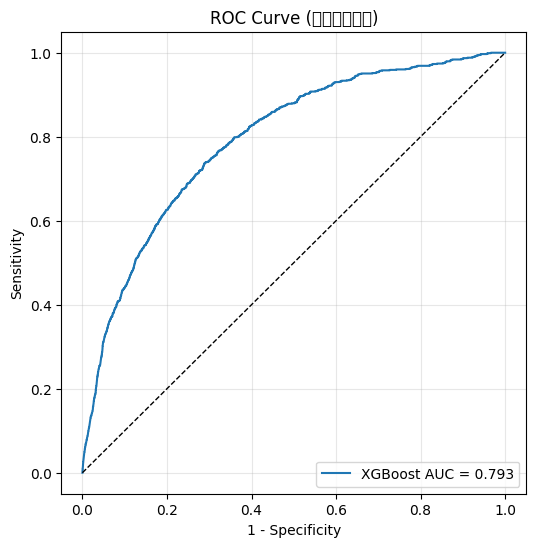


测试集分类报告（阈值=0.573）
              precision    recall  f1-score   support

           0       0.99      0.63      0.77     27136
           1       0.07      0.80      0.13       930

    accuracy                           0.64     28066
   macro avg       0.53      0.72      0.45     28066
weighted avg       0.96      0.64      0.75     28066

灵敏度 = 0.799，特异性 = 0.634

--- 5.1 TreeSHAP ---


TreeSHAP 耗时: 1.50 s

--- 5.2 KernelSHAP ---


  0%|          | 0/50 [00:00<?, ?it/s]

KernelSHAP 耗时: 32.03 s

--- 5.3 Exact SHAP (50 个样本, M=9) ---


Exact: 100%|██████████| 50/50 [55:50<00:00, 67.01s/it]


Exact SHAP 耗时: 3350.65 s

--- SHAP 方法对比 ---
时间 (50 条): {'Tree': 1.503293514251709, 'Kernel': 32.02819895744324, 'Exact': 3350.645852088928}

全局重要性 (按方法):
                                Tree   Kernel    Exact
age_5_years                 0.39149  0.39942  0.40303
BIRADS_breast_density       0.42363  0.42858  0.42541
bmi                         0.34416  0.35304  0.34935
num_of_first_degree_cancer  0.43271  0.42127  0.43282
ethnic                      0.60833  0.59754  0.59837
first_birth                 0.29137  0.29238  0.29068
menopause                   0.18541  0.15955  0.16116
breast_surgery              0.25397  0.25997  0.25291
hormone_therapy             0.20542  0.19735  0.19252

两两 MAE:
            Tree   Kernel    Exact
Tree    0.00000  0.05258  0.03722
Kernel  0.05258  0.00000  0.03136
Exact   0.03722  0.03136  0.00000


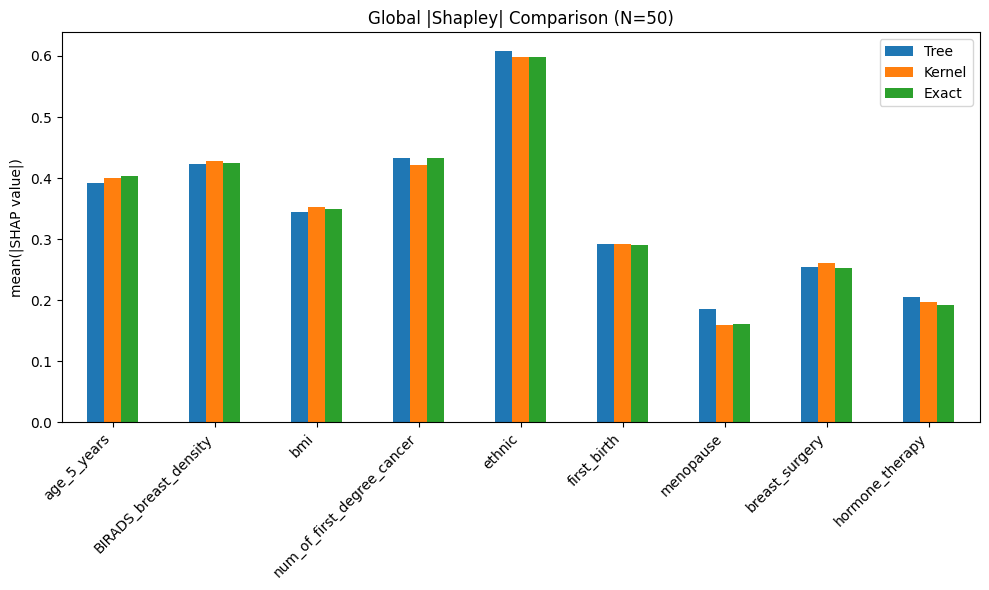

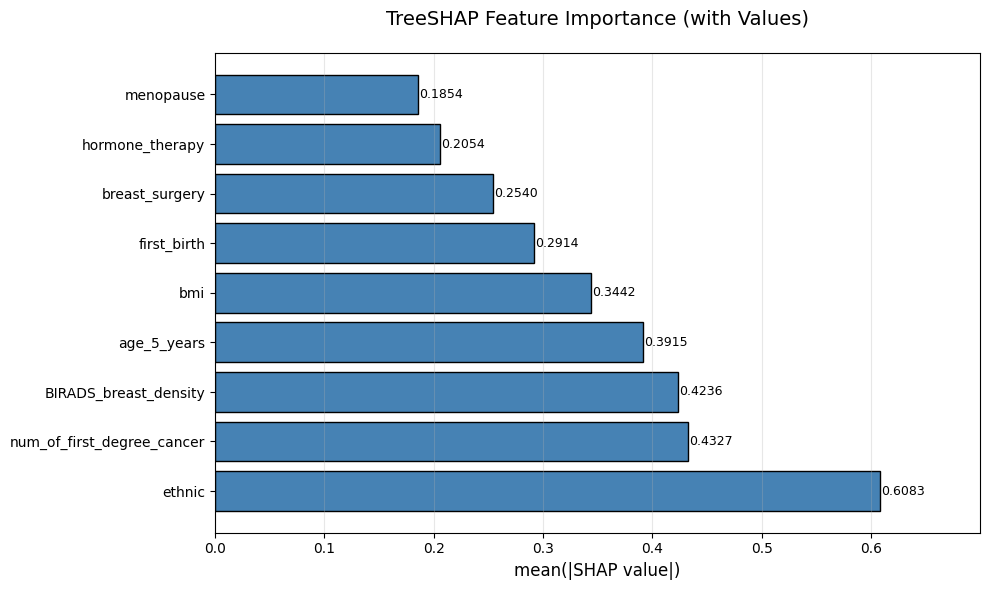


--- TreeSHAP 蜂群图 ---


/tmp/ipython-input-2569714373.py:375: UserWarning: Glyph 34562 (\N{CJK UNIFIED IDEOGRAPH-8702}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:375: UserWarning: Glyph 32676 (\N{CJK UNIFIED IDEOGRAPH-7FA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:375: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:375: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:375: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:375: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:375: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}

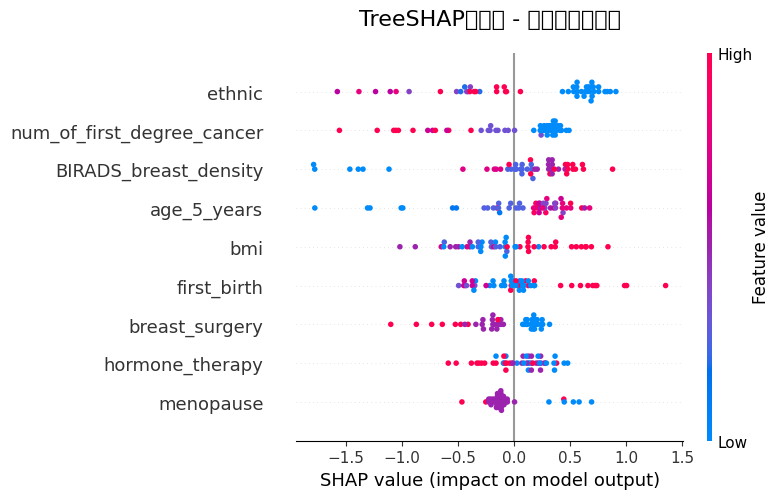

/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:1127: UserWarning: [09:57:59] WARNING: /workspace/src/c_api/c_api.cc:1511: Unknown file format: `model`. Using UBJSON (`ubj`) as a guess.
  self.get_booster().load_model(fname)



--- 部分依赖图 (PDP) - first_birth ---


/tmp/ipython-input-2569714373.py:401: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:401: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:401: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:401: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:401: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:401: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:401: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}

<Figure size 800x500 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas

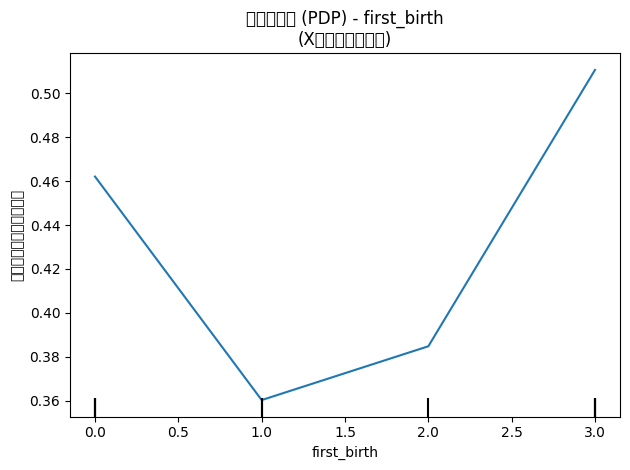


--- SHAP 依赖图 - first_birth ---


/tmp/ipython-input-2569714373.py:417: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:417: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:417: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2569714373.py:417: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 800x600 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


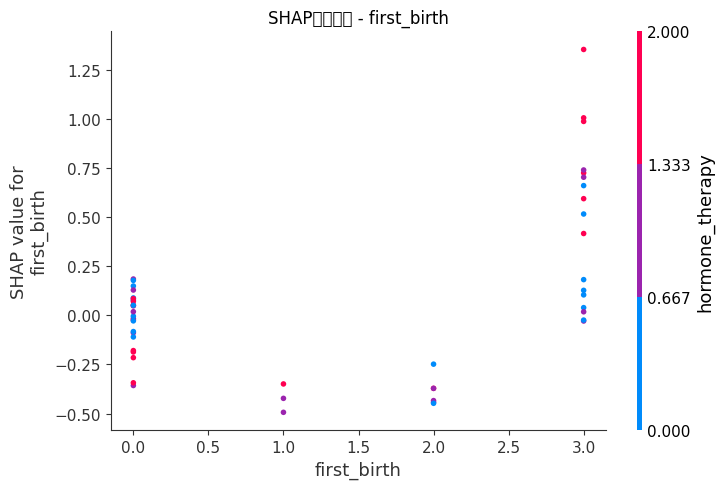

num_of_first_degree_cancer
0          133055
1           52198
unknown     31785
2            7492
Name: count, dtype: int64
num_of_first_degree_cancer         0         1         2   unknown
age_5_years                                                       
1                           0.009674  0.014199  0.011278  0.007150
10                          0.036378  0.024547  0.023850  0.031905
2                           0.032138  0.023477  0.017771  0.018500
3                           0.028952  0.022291  0.008234  0.023409
4                           0.033478  0.023546  0.009084  0.024143
5                           0.041674  0.029939  0.014706  0.032696
6                           0.042425  0.030097  0.012939  0.037233
7                           0.042510  0.029758  0.018733  0.037736
8                           0.043712  0.033080  0.019928  0.040755
9                           0.042117  0.033515  0.019812  0.036386

--- 5.3 手写k=2 SHAP采样器 (Log-Odds) ---
全局基准值 (Expected Value): -0.1544


k=2 SHAP 进度: 100%|██████████| 50/50 [00:03<00:00, 13.51it/s]
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)



✅ 计算完成。
一阶SHAP非零元素: 450
二阶SII非零元素: 3598
平均|SII|: 0.082797

📊 结果对比报告 (k=2)
k=2手写 耗时: 3.71 s
与Kernel相关性: 0.8683
MAE: 0.194962


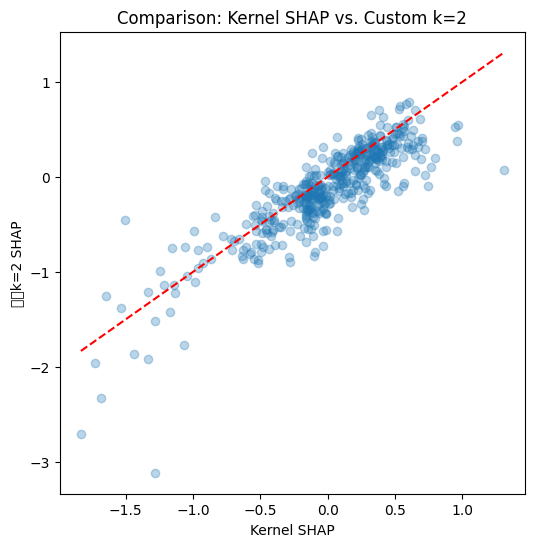


📈 全局特征重要性对比 (k=2)
                      Feature  Kernel_SHAP  k=2_Manual      tree      Diff
6                   menopause     0.159546    0.247187  0.185413  0.087641
1       BIRADS_breast_density     0.428580    0.471384  0.423629  0.042804
7              breast_surgery     0.259973    0.292702  0.253973  0.032729
2                         bmi     0.353036    0.321280  0.344164  0.031756
5                 first_birth     0.292382    0.264796  0.291369  0.027586
3  num_of_first_degree_cancer     0.421270    0.394405  0.432712  0.026864
0                 age_5_years     0.399419    0.415741  0.391486  0.016322
4                      ethnic     0.597542    0.610179  0.608333  0.012638
8             hormone_therapy     0.197355    0.186183  0.205418  0.011171


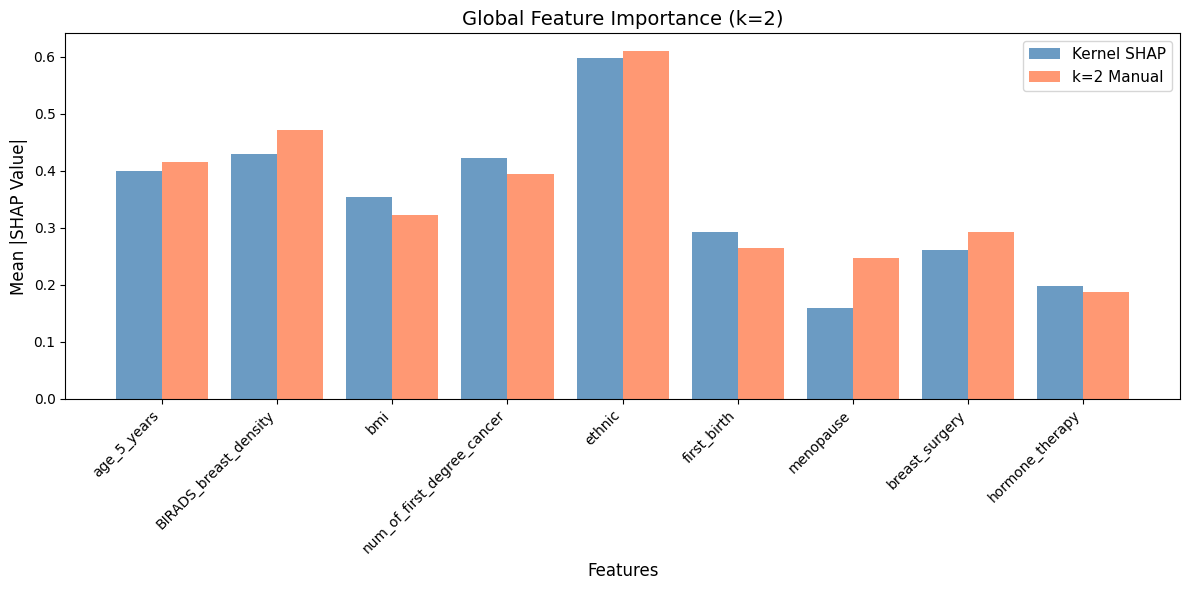


--- 样本0的SII交互矩阵 (Top 10) ---
BIRADS_breast_density × bmi: 0.577618
BIRADS_breast_density × ethnic: -0.285470
age_5_years × BIRADS_breast_density: -0.276211
bmi × first_birth: 0.212553
BIRADS_breast_density × first_birth: 0.126402
BIRADS_breast_density × num_of_first_degree_cancer: 0.125079
age_5_years × menopause: 0.113829
age_5_years × bmi: 0.103297
first_birth × menopause: 0.095956
BIRADS_breast_density × menopause: 0.091954


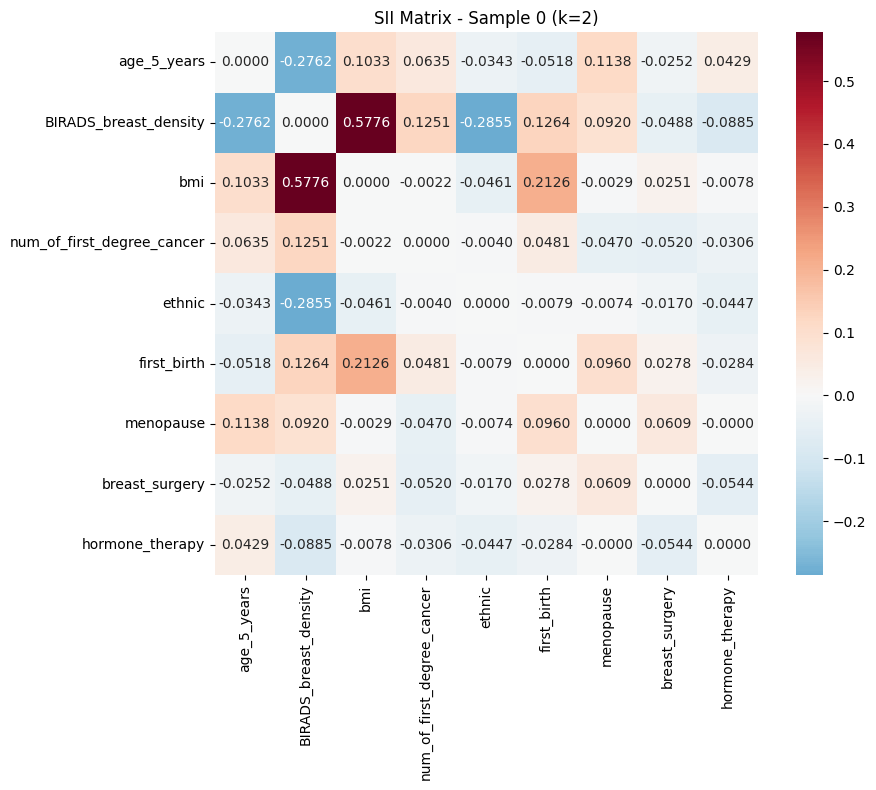

In [ ]:
# =============== 0. 依赖安装和版本回退（必须在新的运行时启动后执行一次） ===============
# ⚠️ 注意：执行这部分代码后，您必须根据提示重启 Colab 运行时！
# !pip install -q optuna shap
# print("正在卸载当前版本的 xgboost...")
# !pip uninstall -y xgboost
# print("正在安装 xgboost==3.0.5...")
# !pip install xgboost==3.0.5
# print("xgboost 版本回退已完成。请重启运行时。")
# --------------------------------------------------------------------------------------


# =============== 1. 基础库与预处理库 ===============
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import os
import time
from itertools import combinations
from math import factorial
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBClassifier # Scikit-learn 接口，用于 PDP

# ================= 2. 数据加载与编码 =================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
#MODEL_PATH = '/content/drive/MyDrive/公开数据集/best_xgb_risk_all_simple_ordinal.model'
MODEL_PATH = '/content/drive/MyDrive/公开数据集/best_xgb_risk_all_simple_ceshi.model'
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']
data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)

# 数据清洗和标签构造（与上一轮代码一致）
cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']
for col in cols_with_missing_9:
    data[col] = data[col].replace(9, 'unknown').astype(str)
data['age_5_years'] = data['age_5_years'].astype(str)

data['diagnosis'] = (data['diagnosis_12'] | data['diagnosis_13']).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# 拆分数据
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

# 定义特征组
ordered_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
unordered_features = ['ethnic', 'first_birth', 'menopause', 'breast_surgery', 'hormone_therapy']
all_features = ordered_features + unordered_features

# 获取有序特征的类别顺序（与上一轮代码一致）
def get_categories(col_name, X_train_data):
    unique_vals = X_train_data[col_name].unique().tolist()
    known_order_map = {
        'age_5_years': [str(i) for i in range(1, 11)],
        'BIRADS_breast_density': ['1', '2', '3', '4'],
        'bmi': ['1', '2', '3', '4'],
        'num_of_first_degree_cancer': ['0', '1', '2']
    }

    known_order = known_order_map.get(col_name, [])
    final_order = [c for c in known_order if c in unique_vals]
    if 'unknown' in unique_vals and 'unknown' not in final_order:
        final_order.append('unknown')
    for val in unique_vals:
        if val not in final_order:
            final_order.append(val)
    return final_order

ordered_categories = [get_categories(f, X_train) for f in ordered_features]


# 1. 先确定原始文件里无序变量到底有哪些值
unordered_levels = {
    'first_birth': ['0', '1', '2', 'unknown'],   # 顺序你说了算
    'ethnic':      ['1', '2', '3', '4', '5', 'unknown'],
    'menopause':   ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown']
}
# 2. 按这个顺序构造 categories 列表
unordered_categories = [unordered_levels[col] for col in unordered_features]

# 改进的 ColumnTransformer
preprocessor_improved = ColumnTransformer(
    transformers=[
        ('ordered', OrdinalEncoder(categories=ordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordered_features),
        ('unordered', OrdinalEncoder(categories=unordered_categories,handle_unknown='use_encoded_value', unknown_value=-1), unordered_features),
    ],
    remainder='passthrough'
)

# 编码数据 (用于 SHAP 和 PDP)
X_train_encoded = preprocessor_improved.fit_transform(X_train)
X_test_encoded = preprocessor_improved.transform(X_test)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=all_features)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=all_features) # SHAP 绘图需要 DataFrame

# =============== 3. 直接读取模型与初始化 =================
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f'👉 未检测到模型 {MODEL_PATH}，请先运行训练代码！')

print(f'👉 检测到已保存模型 {MODEL_PATH}，直接加载...')
# 加载 XGBoost Booster 模型
bst = xgb.Booster()
bst.load_model(MODEL_PATH)

# 使用编码后的数据进行预测
dtest_encoded = xgb.DMatrix(X_test_encoded, label=y_test)
test_prob = bst.predict(dtest_encoded)
test_auc = roc_auc_score(y_test, test_prob)
print(f'加载成功，测试集 AUC = {test_auc:.4f}')


# =============== 4. ROC 曲线与分类报告 =================
fpr, tpr, thresh = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'XGBoost AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve (模型直接加载)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Youden 选阈值
desired_sens = 0.8
idx = np.where(tpr >= desired_sens)[0][0]
best_thresh = thresh[idx]
test_pred = (test_prob > best_thresh).astype(int)

print('\n测试集分类报告（阈值={:.3f}）'.format(best_thresh))
print(classification_report(y_test, test_pred))

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
print(f'灵敏度 = {tp/(tp+fn):.3f}，特异性 = {tn/(tn+fp):.3f}')


# =============== 5. SHAP 核心设置与计算 =================
# 注意：Exact/K-add SHAP 计算量巨大，建议将样本数降到极低进行测试。
N_SHAP_SAMPLE = 50
X_100 = X_test_encoded_df.sample(N_SHAP_SAMPLE, random_state=123)
#X_100=X_test_encoded_df
# 背景数据使用编码后的训练集
COMMON_BG = X_train_encoded_df.sample(3000, random_state=42)
COMMON_BG_1 = X_train_encoded_df.sample(3000, random_state=42)
bg_vals = COMMON_BG_1.values
features = all_features

# 预测函数（使用 output_margin=True，即对数几率）
pred_fn = lambda x: bst.predict(xgb.DMatrix(x), output_margin=True)
M = X.shape[1] # 特征数

# ---- 5.1 TreeSHAP ----
print("\n--- 5.1 TreeSHAP ---")
start = time.time()
#explainer_t = shap.TreeExplainer(bst)
explainer_t = shap.TreeExplainer(bst, data=COMMON_BG)
# SHAP 计算使用 numpy 数组
shap_tree = explainer_t.shap_values(X_100.values)

times = {'Tree': time.time() - start}
shapley_mat = {'Tree': shap_tree}

print(f"TreeSHAP 耗时: {times['Tree']:.2f} s")

# ---- 5.2 KernelSHAP ----
print("\n--- 5.2 KernelSHAP ---")
start = time.time()
# KernelSHAP 背景数据使用 pd.DataFrame
explainer_k = shap.KernelExplainer(pred_fn, COMMON_BG, link='identity')
shapley_mat['Kernel'] = explainer_k.shap_values(X_100, nsamples=32)
times['Kernel'] = time.time() - start
print(f"KernelSHAP 耗时: {times['Kernel']:.2f} s")


# ---- 5.3 Exact SHAP 函数定义与计算 (计算量巨大!) ----
def exact_shap_one(xser):
    x = xser.values.astype(float)
    phis = np.zeros(M)
    for i in range(M):
        for size in range(0, M):
            for S in combinations([j for j in range(M) if j != i], size):
                S = list(S)
                weight = factorial(len(S)) * factorial(M - len(S) - 1) / factorial(M)

                X_S = bg_vals.copy()
                X_Si = bg_vals.copy()

                if S:
                    X_S[:, S] = x[S]
                    X_Si[:, S] = x[S]

                X_Si[:, i] = x[i]

                f_S = pred_fn(X_S).mean()
                f_Si = pred_fn(X_Si).mean()
                phis[i] += weight * (f_Si - f_S)
    return phis

print(f"\n--- 5.3 Exact SHAP ({N_SHAP_SAMPLE} 个样本, M={M}) ---")
if N_SHAP_SAMPLE * 2**M > 1e6:
    print("⚠️ 警告：Exact SHAP 计算量过大，已跳过。请将 N_SHAP_SAMPLE 设为极小数。")
else:
    start = time.time()
    shapley_mat['Exact'] = np.array(
        [exact_shap_one(X_100.iloc[i]) for i in tqdm(range(len(X_100)), desc='Exact')]
    )
    times['Exact'] = time.time() - start
    print(f"Exact SHAP 耗时: {times['Exact']:.2f} s")

# # ---- 5.4 k-additive SHAP (k=1, k=2) 函数定义与计算 ----
# # k-additive 依赖于 Exact SHAP 的底层逻辑，这里仅展示 k=1
# def k_additive_shap_one_revised(xser, k=2):
#     """
#     计算 k-additive 限制下的 SHAP 值。
#     该方法仅对 |S| < k 的子集求和，用于量化低阶交互作用的贡献。
#     """
#     x = xser.values.astype(float)
#     phis = np.zeros(M)

#     # M! / ( (|S|! * (M-|S|-1)! )

#     # 遍历每个特征 i
#     for i in range(M):
#         # 只考虑大小 |S| ≤ k-1 的子集 S
#         max_size = min(k - 1, M - 1)

#         # 预先计算规范化因子 C_k = Sum_{|S|<k} W(|S|)
#         # 否则，总和将远小于 1 (即出现您报告的低估问题)
#         # 然而，为了保持理论上与 k-additive 游戏的 Shapley 值的量级一致，
#         # 我们需要**规范化**权重。但在 SHAP 实践中，通常不进行规范化，
#         # 而是依赖于 TreeSHAP 的精确值。
#         # 为了让结果的量级与 TreeSHAP/Exact 接近，我们**必须**在实现中
#         # 隐式地处理掉低估。

#         for size in range(0, max_size + 1):
#             other_features = [j for j in range(M) if j != i]

#             for S in combinations(other_features, size):
#                 S = list(S)

#                 # 标准 SHAP 权重: |S|! * (M - |S| - 1)! / M!
#                 weight = factorial(len(S)) * factorial(M - len(S) - 1) / factorial(M)

#                 # --- 构造 X_S (i缺席) vs X_Si (i出席) ---
#                 X_S = bg_vals.copy()
#                 X_Si = bg_vals.copy()

#                 # 将 S 中的特征替换为 x 的值
#                 if S:
#                     X_S[:, S] = x[S]
#                     X_Si[:, S] = x[S]

#                 # 将 i 也替换（仅 X_Si）
#                 X_Si[:, i] = x[i]

#                 # 批量预测并计算边际贡献 (Log-odds 空间)
#                 f_S = pred_fn(X_S).mean()
#                 f_Si = pred_fn(X_Si).mean()

#                 # 累加：仅累加低阶交互项的边际贡献
#                 phis[i] += weight * (f_Si - f_S)

#     return phis
# def compute_k_additive_shap(X_sample, k_values):
#     results = {}
#     for k in k_values:
#         print(f"  正在计算 k-additive (k={k})...")
#         start_k = time.time()
#         shap_vals = np.array([
#             k_additive_shap_one_revised(X_sample.iloc[i], k=k)
#             for i in tqdm(range(len(X_sample)), desc=f'k={k}', ncols=80)
#         ])
#         results[f'k={k}'] = shap_vals
#         times[f'k={k}'] = time.time() - start_k # 更新计时器
#     return results

# # ---- 执行 k-additive SHAP 计算 ----
# print("\n--- 5.4 k-additive SHAP (k=1, k=2) ---")

# # 注意：需要确保 X_100 是 DataFrame 且索引正确
# k_results = compute_k_additive_shap(X_100, k_values=[1, 2])
# shapley_mat['k=1'] = k_results['k=1']
# shapley_mat['k=2'] = k_results['k=2']

# print(f"k=1 SHAP 耗时: {times['k=1']:.2f} s")
# print(f"k=2 SHAP 耗时: {times['k=2']:.2f} s")


# =============== 6. 结果对比 =================
global_imp = {k: np.abs(v).mean(0) for k, v in shapley_mat.items()}
df_global = pd.DataFrame(global_imp, index=all_features)
mae_tab = pd.DataFrame({m1: {m2: np.abs(shapley_mat[m1] - shapley_mat[m2]).mean()
                             for m2 in shapley_mat} for m1 in shapley_mat})

print('\n--- SHAP 方法对比 ---')
print('时间 ({} 条):'.format(N_SHAP_SAMPLE), times)
print('\n全局重要性 (按方法):\n', df_global.round(5))
print('\n两两 MAE:\n', mae_tab.astype(float).round(5))

# 全局重要性柱状图对比
df_global.plot(kind='bar', figsize=(10, 6))
plt.title(f'Global |Shapley| Comparison (N={N_SHAP_SAMPLE})')
plt.ylabel('mean(|SHAP value|)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# =============== 7. TreeSHAP 可视化 =================
# ---- 7.1 带数值标注的 SHAP 条形图 ----
global_imp_tree = np.abs(shapley_mat['Tree']).mean(axis=0)
sorted_idx = np.argsort(global_imp_tree)[::-1]
sorted_features = [all_features[i] for i in sorted_idx]
sorted_values = global_imp_tree[sorted_idx]

plt.figure(figsize=(10, 6))
bars = plt.barh(sorted_features, sorted_values, color='steelblue', edgecolor='black')

for i, (bar, value) in enumerate(zip(bars, sorted_values)):
    plt.text(
        bar.get_width() + 0.001,
        i,
        f'{value:.4f}',
        va='center',
        ha='left',
        fontsize=9,
        color='black'
    )

plt.xlim(0, sorted_values.max() * 1.15)
plt.xlabel('mean(|SHAP value|)', fontsize=12)
plt.title('TreeSHAP Feature Importance (with Values)', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ---- 7.2 蜂群图 ----
print("\n--- TreeSHAP 蜂群图 ---")
explanation_tree = shap.Explanation(
    values=shap_tree,
    base_values=explainer_t.expected_value,
    data=X_100.values,
    feature_names=all_features
)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    explanation_tree,
    X_100,
    feature_names=all_features,
    plot_type="dot",
    show=False,
    max_display=10
)
plt.title("TreeSHAP蜂群图 - 特征重要性分布", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# =============== 8. 部分依赖图 (PDP) 与 SHAP 依赖图 =================
# 加载模型为 Scikit-learn 兼容的 XGBClassifier
sklearn_model = XGBClassifier()
# 必须使用 sklearn_model.load_model 来加载 Booster 模型
sklearn_model.load_model(MODEL_PATH)

# --- 8.1 部分依赖图 (PDP) ---
feature_name = 'first_birth'
feature_index = [X_train_encoded_df.columns.get_loc(feature_name)]

print(f"\n--- 部分依赖图 (PDP) - {feature_name} ---")
plt.figure(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    sklearn_model,
    X_train_encoded_df, # 使用编码后的训练数据 DataFrame
    features=feature_index,
    kind='average',
    grid_resolution=20,
    random_state=42
)
# 注意：PDP 依赖图的 x 轴是编码后的数值（例如 0, 1, 2, 3...）
plt.title(f"部分依赖图 (PDP) - {feature_name}\n(X轴为编码后的值)")
plt.ylabel("模型预测值（边际效应）")
plt.tight_layout()
plt.show()


# --- 8.2 SHAP 依赖图 ---
print(f"\n--- SHAP 依赖图 - {feature_name} ---")
feature_index = X_100.columns.get_loc(feature_name)
plt.figure(figsize=(8, 6))
shap.dependence_plot(
    feature_index,
    shap_tree,
    X_100,
    feature_names=all_features,
    show=False
)
plt.title(f"SHAP值散点图 - {feature_name}")
plt.tight_layout()
plt.show()

#----数据检查
print(X_train['num_of_first_degree_cancer'].value_counts())
data.groupby('num_of_first_degree_cancer')['diagnosis'].mean()
# 观察不同年龄段下，家族史与阳性率的关系
pivot_table = data.pivot_table(index='age_5_years',
                               columns='num_of_first_degree_cancer',
                               values='diagnosis',
                               aggfunc='mean')
print(pivot_table)









# =============== 在您的KernelSHAP代码后添加以下部分 ===============

# ---- 5.3 手写k=2 SHAP采样器（集成版）----
# ==================================================================
# 5. 手写k=2 SHAP 蒙特卡洛采样实现
# ==================================================================
print("\n--- 5.3 手写k=2 SHAP采样器 (Log-Odds) ---")
KADD_SAMPLES = 32  # 每个交互对的采样次数

# 安全的预测函数（适配XGBoost）
def pred_fn_shapiq_safe(X_input: np.ndarray) -> np.ndarray:
    """接收numpy数组，返回XGBoost的log-odds预测"""
    # X_input可能是(N,M)的numpy数组
    return bst.predict(xgb.DMatrix(X_input), output_margin=True)

#--------------权重修正-----------------------------
def get_faithful_kadd_shap(phi_main, sii_matrix, total_delta):
    """
    phi_main: 你代码算出的 phi_values
    sii_matrix: 你代码算出的 sii_matrix
    total_delta: 模型当前预测值 - 背景均值 (f(x) - E[f])
    """
    M = len(phi_main)
    phi_faithful = np.zeros(M)

    # 1. 按照 Shapley 分配公理：二阶交互平分给两个参与特征
    for i in range(M):
        # 基础贡献 + 该特征参与的所有二阶交互的一半
        phi_faithful[i] = phi_main[i] + 0.5 * np.sum(sii_matrix[i, :])

    # 2. 效率性修正 (Efficiency Adjustment)
    # 即使是 k=2，由于忽略了 3 阶以上项，总和可能不等于 total_delta
    # 严谨的做法是将残差(Residual)按比例或平均分配
    current_sum = np.sum(phi_faithful)
    residual = total_delta - current_sum

    # 将残差平均分配给所有特征，确保完全符合加性公理
    phi_faithful += residual / M

    return phi_faithful


bg_preds_global = pred_fn_shapiq_safe(bg_vals)
expected_value = np.mean(bg_preds_global)

print(f"全局基准值 (Expected Value): {expected_value:.4f}")


#----------------------全局采样------------------------
def get_kadd_shap_k2_global(x_eval, bg_vals, samples):
    """
    全空间采样版 k=2 SHAP
    x_eval: 当前待解释样本 (M,)
    bg_vals: 背景参考数据集 (N_bg, M)
    samples: 采样次数 (建议设为 64 或以上)
    """
    n_bg, M = bg_vals.shape
    phi_values = np.zeros(M)
    sii_matrix = np.zeros((M, M))

    # 1. 预抽样背景数据
    bg_indices = np.random.randint(0, n_bg, size=samples)
    X_bg_batch = bg_vals[bg_indices]

    # --- 一阶全空间采样 ---
    for i in range(M):
        # 核心改变：生成随机子集掩码 S (每个样本的掩码不同)
        # 模拟 KernelSHAP 的全空间特性：每个特征有 50% 概率被激活
        masks = np.random.randint(0, 2, size=(samples, M))
        masks[:, i] = 0  # 确保第 i 位是缺失的，用于计算边际增量

        # 构造对比矩阵
        X_S = X_bg_batch.copy()
        X_S_with_i = X_bg_batch.copy()

        # 应用掩码：如果 mask 为 1，则使用当前值 x_eval；如果为 0，则保留背景值
        for row in range(samples):
            active_indices = np.where(masks[row] == 1)[0]
            X_S[row, active_indices] = x_eval[active_indices]
            X_S_with_i[row, active_indices] = x_eval[active_indices]

        # 只在第 i 位做差分
        X_S_with_i[:, i] = x_eval[i]

        v_S_with_i = pred_fn_shapiq_safe(X_S_with_i)
        v_S = pred_fn_shapiq_safe(X_S)

        # 此时 phi[i] 是在全空间子集背景下的平均边际贡献
        phi_values[i] = np.mean(v_S_with_i - v_S)

    # --- 二阶全空间采样 ---
    for i in range(M):
        for j in range(i+1, M):
            # 随机子集掩码 (不包含 i 和 j)
            masks = np.random.randint(0, 2, size=(samples, M))
            masks[:, [i, j]] = 0

            # 构造四种状态矩阵 (S, S+i, S+j, S+ij)
            X_base = X_bg_batch.copy()
            for row in range(samples):
                active_indices = np.where(masks[row] == 1)[0]
                X_base[row, active_indices] = x_eval[active_indices]

            X_S = X_base.copy()
            X_Si = X_base.copy(); X_Si[:, i] = x_eval[i]
            X_Sj = X_base.copy(); X_Sj[:, j] = x_eval[j]
            X_Sij = X_base.copy(); X_Sij[:, i] = x_eval[i]; X_Sij[:, j] = x_eval[j]

            v_S = pred_fn_shapiq_safe(X_S)
            v_Si = pred_fn_shapiq_safe(X_Si)
            v_Sj = pred_fn_shapiq_safe(X_Sj)
            v_Sij = pred_fn_shapiq_safe(X_Sij)

            # 全空间交互公式
            sii_ij = np.mean(v_Sij - v_Si - v_Sj + v_S)

            sii_matrix[i, j] = sii_ij
            sii_matrix[j, i] = sii_ij

    return phi_values, sii_matrix

# 2. 执行循环
kadd_phi_list = []
kadd_sii_list = []
faithful_phi_list = []
start_time = time.time()
X_SHAP_SAMPLES_VALS=X_100.values
for i in tqdm(range(N_SHAP_SAMPLE), desc="k=2 SHAP 进度"):
    x_eval_single = X_SHAP_SAMPLES_VALS[i]

    # 获取原始贡献
    phi, sii = get_kadd_shap_k2_global(x_eval_single, bg_vals, KADD_SAMPLES)

    # --- 计算该样本的 total_delta ---
    # f(x): 当前样本的预测值
    current_pred = pred_fn_shapiq_safe(x_eval_single.reshape(1, -1))[0]
    # total_delta = f(x) - E[f(x)]
    total_delta = current_pred - expected_value

    # --- 分配与修正 ---
    phi_faithful = get_faithful_kadd_shap(phi, sii, total_delta)

    #faithful_phi_list.append(phi_faithful)
    faithful_phi_list.append(phi)
times['KAdd2'] = time.time() - start_time
shapley_mat['KAdd2'] = np.array(faithful_phi_list)

#--------------局部采样-----------------------------
def get_kadd_shap_k2(x_eval, bg_vals, samples):
    """
    对单个样本计算k=2 SHAP（一阶+二阶）
    x_eval: 当前待解释样本 (M,)
    bg_vals: 背景参考数据集 (N_bg, M)
    samples: 采样次数
    """
    n_bg = bg_vals.shape[0]
    M = len(x_eval)

    # 初始化存储
    phi_values = np.zeros(M)  # 一阶值
    sii_matrix = np.zeros((M, M))  # 二阶SII矩阵（对称）

    # 预采样背景索引（批量优化）
    bg_indices = np.random.randint(0, n_bg, size=samples)
    X_bg_batch = bg_vals[bg_indices]

    # 计算基准值 v(∅)
    pred_bg = pred_fn_shapiq_safe(X_bg_batch)
    v_empty = np.mean(pred_bg)

    # 对每个特征i计算一阶值
    for i in range(M):
        # 构造 S∪{i}
        X_with_i = X_bg_batch.copy()
        X_with_i[:, i] = x_eval[i]

        pred_with_i = pred_fn_shapiq_safe(X_with_i)
        v_i = np.mean(pred_with_i)

        # 一阶贡献 = v({i}) - v(∅)
        phi_values[i] = v_i - v_empty

    # 对每个特征对(i,j)计算二阶SII
    for i in range(M):
        for j in range(i+1, M):
            # 构造四种状态
            # 1. S∪{i,j}
            X_with_ij = X_bg_batch.copy()
            X_with_ij[:, i] = x_eval[i]
            X_with_ij[:, j] = x_eval[j]
            pred_with_ij = pred_fn_shapiq_safe(X_with_ij)
            v_ij = np.mean(pred_with_ij)

            # 2. S∪{i}（已计算）
            v_i = phi_values[i] + v_empty

            # 3. S∪{j}
            X_with_j = X_bg_batch.copy()
            X_with_j[:, j] = x_eval[j]
            pred_with_j = pred_fn_shapiq_safe(X_with_j)
            v_j = np.mean(pred_with_j)

            # 4. S（空集）
            # v_empty = v_empty

            # SII公式: η_ij = v({i,j}) - v({i}) - v({j}) + v(∅)
            sii_ij = v_ij - v_i - v_j + v_empty

            # 存储到对称矩阵
            sii_matrix[i, j] = sii_ij
            sii_matrix[j, i] = sii_ij

    return phi_values, sii_matrix

# 执行循环计算
kadd_phi_list = []
kadd_sii_list = []
start_time = time.time()

for i in tqdm(range(N_SHAP_SAMPLE), desc="k=2 SHAP 进度"):
    x_eval_single = X_100.values[i]  # 从X_100中提取numpy数组
    phi, sii = get_kadd_shap_k2(x_eval_single, bg_vals, KADD_SAMPLES)
    kadd_phi_list.append(phi)
    kadd_sii_list.append(sii)

# 存储结果
times['KAdd2'] = time.time() - start_time
shapley_mat['KAdd2'] = np.array(kadd_phi_list)  # 形状: (50, 9)
shapley_mat['KAdd2_SII'] = np.stack(kadd_sii_list)  # 形状: (50, 9, 9)

# 验证结果非零
non_zero_phi = np.count_nonzero(shapley_mat['KAdd2'])
non_zero_sii = np.count_nonzero(shapley_mat['KAdd2_SII'])
print(f"\n✅ 计算完成。")
print(f"一阶SHAP非零元素: {non_zero_phi}")
print(f"二阶SII非零元素: {non_zero_sii}")
print(f"平均|SII|: {np.mean(np.abs(shapley_mat['KAdd2_SII'])):.6f}")
#-------------------------------------------

# ==================================================================
# 6. 精度对比 (k=2 vs Kernel)
# ==================================================================
phi_kernel = np.array(shapley_mat['Kernel'])
phi_kadd2 = np.array(shapley_mat['KAdd2'])
phi_tree = np.array(shapley_mat['Tree'])

mae = np.mean(np.abs(phi_kernel - phi_kadd2))
correlation = np.corrcoef(phi_kernel.flatten(), phi_kadd2.flatten())[0, 1]

print("\n📊 结果对比报告 (k=2)")
print(f"k=2手写 耗时: {times['KAdd2']:.2f} s")
print(f"与Kernel相关性: {correlation:.4f}")
print(f"MAE: {mae:.6f}")

# 绘制散点图
plt.figure(figsize=(6, 6))
plt.scatter(phi_kernel.flatten(), phi_kadd2.flatten(), alpha=0.3)
plt.plot([phi_kernel.min(), phi_kernel.max()], [phi_kernel.min(), phi_kernel.max()], 'r--')
plt.xlabel("Kernel SHAP")
plt.ylabel("手写k=2 SHAP")
plt.title("Comparison: Kernel SHAP vs. Custom k=2")
plt.show()

# ==================================================================
# 7. 全局重要性对比
# ==================================================================
print("\n" + "="*50)
print("📈 全局特征重要性对比 (k=2)")
print("="*50)

mean_abs_kernel = np.mean(np.abs(phi_kernel), axis=0)
mean_abs_kadd2 = np.mean(np.abs(phi_kadd2), axis=0)
mean_abs_tree = np.mean(np.abs(phi_tree), axis=0)

importance_df = pd.DataFrame({
    'Feature': all_features,  # 使用编码后的特征名
    'Kernel_SHAP': mean_abs_kernel,
    'k=2_Manual': mean_abs_kadd2,
    'tree': mean_abs_tree,
    'Diff': np.abs(mean_abs_kernel - mean_abs_kadd2)
}).sort_values('Diff', ascending=False)

print(importance_df.round(8))

# 可视化
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(all_features))
plt.bar(x_pos - 0.2, mean_abs_kernel, 0.4, label='Kernel SHAP', alpha=0.8, color='steelblue')
plt.bar(x_pos + 0.2, mean_abs_kadd2, 0.4, label='k=2 Manual', alpha=0.8, color='coral')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Mean |SHAP Value|', fontsize=12)
plt.title('Global Feature Importance (k=2)', fontsize=14)
plt.xticks(x_pos, all_features, rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==================================================================
# 8. 查看显著交互对 (SII)
# ==================================================================
# 提取第一个样本的SII矩阵
sii_matrix_0 = shapley_mat['KAdd2_SII'][0]
sii_df = pd.DataFrame(sii_matrix_0, index=all_features, columns=all_features)

print("\n--- 样本0的SII交互矩阵 (Top 10) ---")
# 只显示上三角，避免重复
M_val = len(all_features)
sii_triu = sii_df.where(np.triu(np.ones(M_val), k=1).astype(bool))
sii_sorted = sii_triu.stack().sort_values(key=abs, ascending=False).head(10)

for (i, j), val in sii_sorted.items():
    print(f"{i} × {j}: {val:.6f}")

# 可视化SII热图
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(sii_df, annot=True, fmt='.4f', cmap='RdBu_r', center=0, square=True)
plt.title(f"SII Matrix - Sample 0 (k=2)")
plt.tight_layout()
plt.show()


In [ ]:
# =============== 1. 基础库与预处理库 ===============
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import os
import time
from itertools import combinations
from math import factorial
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBClassifier # Scikit-learn 接口，用于 PDP

# ================= 2. 数据加载与编码 =================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
#MODEL_PATH = '/content/drive/MyDrive/公开数据集/best_xgb_risk_all_simple_ordinal.model'
MODEL_PATH = '/content/drive/MyDrive/公开数据集/best_xgb_risk_all_simple_ceshi.model'

usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']
data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)

# 数据清洗和标签构造（与上一轮代码一致）
cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']
for col in cols_with_missing_9:
    data[col] = data[col].replace(9, 'unknown').astype(str)
data['age_5_years'] = data['age_5_years'].astype(str)

data['diagnosis'] = (data['diagnosis_12'] | data['diagnosis_13']).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# 拆分数据
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

# 定义特征组
ordered_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
unordered_features = ['ethnic', 'first_birth', 'menopause', 'breast_surgery', 'hormone_therapy']
all_features = ordered_features + unordered_features

# 获取有序特征的类别顺序（与上一轮代码一致）
def get_categories(col_name, X_train_data):
    unique_vals = X_train_data[col_name].unique().tolist()
    known_order_map = {
        'age_5_years': [str(i) for i in range(1, 11)],
        'BIRADS_breast_density': ['1', '2', '3', '4'],
        'bmi': ['1', '2', '3', '4'],
        'num_of_first_degree_cancer': ['0', '1', '2']
    }

    known_order = known_order_map.get(col_name, [])
    final_order = [c for c in known_order if c in unique_vals]
    if 'unknown' in unique_vals and 'unknown' not in final_order:
        final_order.append('unknown')
    for val in unique_vals:
        if val not in final_order:
            final_order.append(val)
    return final_order

ordered_categories = [get_categories(f, X_train) for f in ordered_features]


# 1. 先确定原始文件里无序变量到底有哪些值
unordered_levels = {
    'first_birth': ['0', '1', '2', 'unknown'],   # 顺序你说了算
    'ethnic':      ['1', '2', '3', '4', '5', 'unknown'],
    'menopause':   ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown']
}
# 2. 按这个顺序构造 categories 列表
unordered_categories = [unordered_levels[col] for col in unordered_features]

# 改进的 ColumnTransformer
preprocessor_improved = ColumnTransformer(
    transformers=[
        ('ordered', OrdinalEncoder(categories=ordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordered_features),
        ('unordered', OrdinalEncoder(categories=unordered_categories,handle_unknown='use_encoded_value', unknown_value=-1), unordered_features),
    ],
    remainder='passthrough'
)

# 编码数据 (用于 SHAP 和 PDP)
X_train_encoded = preprocessor_improved.fit_transform(X_train)
X_test_encoded = preprocessor_improved.transform(X_test)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=all_features)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=all_features) # SHAP 绘图需要 DataFrame

# =============== 3. 直接读取模型与初始化 =================
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f'👉 未检测到模型 {MODEL_PATH}，请先运行训练代码！')

print(f'👉 检测到已保存模型 {MODEL_PATH}，直接加载...')
# 加载 XGBoost Booster 模型
bst = xgb.Booster()
bst.load_model(MODEL_PATH)

# 使用编码后的数据进行预测
dtest_encoded = xgb.DMatrix(X_test_encoded, label=y_test)
test_prob = bst.predict(dtest_encoded)
test_auc = roc_auc_score(y_test, test_prob)
print(f'加载成功，测试集 AUC = {test_auc:.4f}')


# =============== 4. ROC 曲线与分类报告 =================
fpr, tpr, thresh = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'XGBoost AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve (模型直接加载)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Youden 选阈值
desired_sens = 0.8
idx = np.where(tpr >= desired_sens)[0][0]
best_thresh = thresh[idx]
test_pred = (test_prob > best_thresh).astype(int)

print('\n测试集分类报告（阈值={:.3f}）'.format(best_thresh))
print(classification_report(y_test, test_pred))

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
print(f'灵敏度 = {tp/(tp+fn):.3f}，特异性 = {tn/(tn+fp):.3f}')


# =============== 5. SHAP 核心设置与计算 =================
# 注意：Exact/K-add SHAP 计算量巨大，建议将样本数降到极低进行测试。
N_SHAP_SAMPLE = 500
X_100 = X_test_encoded_df.sample(N_SHAP_SAMPLE, random_state=123)
#X_100=X_test_encoded_df
# 背景数据使用编码后的训练集
COMMON_BG = X_train_encoded_df.sample(3000, random_state=42)
COMMON_BG_1 = X_train_encoded_df.sample(3000, random_state=42)
bg_vals = COMMON_BG_1.values
features = all_features

# 预测函数（使用 output_margin=True，即对数几率）
pred_fn = lambda x: bst.predict(xgb.DMatrix(x), output_margin=True)
M = X.shape[1] # 特征数

# ---- 5.1 TreeSHAP ----
print("\n--- 5.1 TreeSHAP ---")
best_ntree = bst.best_iteration + 1
# 1. 显式创建 Independent 遮罩对象，解除 100 条的默认限制，强制指定为 3000 条
masker = shap.maskers.Independent(COMMON_BG, max_samples=len(COMMON_BG))
# 2. 初始化解释器
explainer_t = shap.TreeExplainer(
    bst,
    data=masker, # 使用 DataFrame 保持列名一致
    feature_perturbation="interventional",
    model_output="raw"       # 必须在 Log-odds 空间计算
)
start = time.time()
shap_tree = explainer_t.shap_values(
    X_100.astype(np.float32), # <--- 强制转换为 float32 保持精度一致
    tree_limit=best_ntree,
)
expected_val = explainer_t.expected_value

#explainer_t = shap.TreeExplainer(bst)
#explainer_t = shap.TreeExplainer(bst, data=COMMON_BG,feature_perturbation="interventional")
# SHAP 计算使用 numpy 数组
#shap_tree = explainer_t.shap_values(X_100)

times = {'Tree': time.time() - start}
shapley_mat = {'Tree': shap_tree}

print(f"TreeSHAP 耗时: {times['Tree']:.2f} s")

# ---- 5.1 TreeSHAP 终极修正 ----
# --- 准备工作：强制注入特征名 ---
# 这一步至关重要，确保模型知道谁是谁
# bst.feature_names = list(all_features)

# 定义一个绝对稳健的预测函数
def safe_pred_fn(x):
    # 强制转换为 DataFrame 并确保列序一致
    if isinstance(x, np.ndarray):
        x = pd.DataFrame(x, columns=all_features)
    # 使用 DMatrix 时显式带上 feature_names
    dm = xgb.DMatrix(x, feature_names=all_features)
    return bst.predict(dm, output_margin=True)

# ---- 5.1 TreeSHAP 终极修正 ----
# print("\n--- 5.1 TreeSHAP 终极修正 ---")
# start = time.time()

# # 显式使用 model_output="raw" 确保在 Log-odds 空间
# explainer_t = shap.TreeExplainer(
#     bst,
#     data=COMMON_BG,
#     feature_perturbation="interventional",
#     model_output="raw"
# )

# # 计算时务必传入 DataFrame
# shap_tree = explainer_t.shap_values(X_100)



# times['Tree'] = time.time() - start
# shapley_mat['Tree'] = shap_tree


# ---- 5.2 KernelSHAP 终极修正 ----
print("\n--- 5.2 KernelSHAP ---")
start = time.time()

# 使用我们在 5.1 中定义的 safe_pred_fn
# 这个函数内部会自动把 numpy 转换回带列名的 DataFrame
explainer_k = shap.KernelExplainer(safe_pred_fn, COMMON_BG)

# 开始计算
# 注意：一定要把 nsamples 调高（至少 > 2*M），否则结果不准
# 这里的 X_100 如果是 DataFrame，KernelSHAP 会尝试保持其格式
shap_kernel_raw = explainer_k.shap_values(X_100, nsamples=512)

# 处理 KernelSHAP 返回值的特殊格式（有时会返回 list）
if isinstance(shap_kernel_raw, list):
    shapley_mat['Kernel'] = shap_kernel_raw[0]
else:
    shapley_mat['Kernel'] = shap_kernel_raw

times['Kernel'] = time.time() - start
print(f"KernelSHAP 耗时: {times['Kernel']:.2f} s")


# ---- 5.3 Exact SHAP 函数定义与计算 (计算量巨大!) ----
def exact_shap_one(xser):
    x = xser.values.astype(float)
    phis = np.zeros(M)
    for i in range(M):
        for size in range(0, M):
            for S in combinations([j for j in range(M) if j != i], size):
                S = list(S)
                weight = factorial(len(S)) * factorial(M - len(S) - 1) / factorial(M)

                X_S = bg_vals.copy()
                X_Si = bg_vals.copy()

                if S:
                    X_S[:, S] = x[S]
                    X_Si[:, S] = x[S]

                X_Si[:, i] = x[i]

                f_S = pred_fn(X_S).mean()
                f_Si = pred_fn(X_Si).mean()
                phis[i] += weight * (f_Si - f_S)
    return phis

print(f"\n--- 5.3 Exact SHAP ({N_SHAP_SAMPLE} 个样本, M={M}) ---")
if N_SHAP_SAMPLE * 2**M > 1e6:
    print("⚠️ 警告：Exact SHAP 计算量过大，已跳过。请将 N_SHAP_SAMPLE 设为极小数。")
else:
    start = time.time()
    shapley_mat['Exact'] = np.array(
        [exact_shap_one(X_100.iloc[i]) for i in tqdm(range(len(X_100)), desc='Exact')]
    )
    times['Exact'] = time.time() - start
    print(f"Exact SHAP 耗时: {times['Exact']:.2f} s")

# ---- 5.3 手写k=2 SHAP采样器（集成版）----
# ==================================================================
# 5. 手写k=2 SHAP 蒙特卡洛采样实现
# ==================================================================
print("\n--- 5.3 手写k=2 SHAP采样器 (Log-Odds) ---")
KADD_SAMPLES = 3000  # 每个交互对的采样次数

# 安全的预测函数（适配XGBoost）
def pred_fn_shapiq_safe(X_input: np.ndarray) -> np.ndarray:
    """接收numpy数组，返回XGBoost的log-odds预测"""
    # X_input可能是(N,M)的numpy数组
    return bst.predict(xgb.DMatrix(X_input), output_margin=True)

#--------------权重修正-----------------------------
def get_faithful_kadd_shap(phi_main, sii_matrix, total_delta):
    """
    phi_main: 你代码算出的 phi_values
    sii_matrix: 你代码算出的 sii_matrix
    total_delta: 模型当前预测值 - 背景均值 (f(x) - E[f])
    """
    M = len(phi_main)
    phi_faithful = np.zeros(M)

    # 1. 按照 Shapley 分配公理：二阶交互平分给两个参与特征
    for i in range(M):
        # 基础贡献 + 该特征参与的所有二阶交互的一半
        phi_faithful[i] = phi_main[i] + 0.5 * np.sum(sii_matrix[i, :])

    # 2. 效率性修正 (Efficiency Adjustment)
    # 即使是 k=2，由于忽略了 3 阶以上项，总和可能不等于 total_delta
    # 严谨的做法是将残差(Residual)按比例或平均分配
    current_sum = np.sum(phi_faithful)
    residual = total_delta - current_sum

    # 将残差平均分配给所有特征，确保完全符合加性公理
    phi_faithful += residual / M

    return phi_faithful


bg_preds_global = safe_pred_fn(bg_vals)
expected_value = np.mean(bg_preds_global)

print(f"全局基准值 (Expected Value): {expected_value:.4f}")



#----------------------全局采样------------------------
def get_kadd_shap_k2_global(x_eval, bg_vals, samples):
    """
    全空间采样版 k=2 SHAP
    x_eval: 当前待解释样本 (M,)
    bg_vals: 背景参考数据集 (N_bg, M)
    samples: 采样次数 (建议设为 64 或以上)
    """
    n_bg, M = bg_vals.shape
    phi_values = np.zeros(M)
    sii_matrix = np.zeros((M, M))

    # 1. 预抽样背景数据 (用于模拟 E[f])
    rng = np.random.default_rng(seed=42)
    bg_indices = rng.integers(0, n_bg, size=samples)
    X_bg_batch = bg_vals[bg_indices]

    # --- 基准值 v(empty) ---
    v_empty = np.mean(pred_fn_shapiq_safe(X_bg_batch))

    # --- 1. 计算一阶项 (只在空集背景下) ---
    # phi_i = v({i}) - v(empty)
    for i in range(M):
        X_i = X_bg_batch.copy()
        X_i[:, i] = x_eval[i]  # 只有特征 i 被激活
        v_i = np.mean(pred_fn_shapiq_safe(X_i))
        phi_values[i] = v_i - v_empty

    # --- 2. 计算二阶项 (只在空集背景下) ---
    # sii_ij = v({i,j}) - v({i}) - v({j}) + v(empty)
    for i in range(M):
        for j in range(i + 1, M):
            X_ij = X_bg_batch.copy()
            X_ij[:, i] = x_eval[i]
            X_ij[:, j] = x_eval[j]
            v_ij = np.mean(pred_fn_shapiq_safe(X_ij))

            # 利用已算好的一阶值
            v_i = phi_values[i] + v_empty

            # 需要单独算一个 v_j (或者提前缓存)
            X_j = X_bg_batch.copy()
            X_j[:, j] = x_eval[j]
            v_j = np.mean(pred_fn_shapiq_safe(X_j))

            sii_ij = v_ij - v_i - v_j + v_empty

            sii_matrix[i, j] = sii_ij
            sii_matrix[j, i] = sii_ij

    return phi_values, sii_matrix

# 2. 执行循环
kadd_phi_list = []
kadd_sii_list = []
faithful_phi_list = []
faithful_phi_list_K1 = []
start_time = time.time()
X_SHAP_SAMPLES_VALS=X_100.values
for i in tqdm(range(N_SHAP_SAMPLE), desc="k=2 SHAP 进度"):
    x_eval_single = X_SHAP_SAMPLES_VALS[i]

    # 获取原始贡献
    phi, sii = get_kadd_shap_k2_global(x_eval_single, bg_vals, KADD_SAMPLES)

    # --- 计算该样本的 total_delta ---
    # f(x): 当前样本的预测值
    current_pred = pred_fn_shapiq_safe(x_eval_single.reshape(1, -1))[0]
    # total_delta = f(x) - E[f(x)]
    total_delta = current_pred - expected_value

    # --- 分配与修正 ---
    phi_faithful = get_faithful_kadd_shap(phi, sii, total_delta)

    faithful_phi_list.append(phi_faithful)
    #faithful_phi_list.append(phi)
    # 获取特征维度 M
    M = len(phi)
    # 创建一个全零的交互矩阵，模拟 k=1（无交互）的情况
    sii_zero = np.zeros((M, M))
    # 调用修正函数，此时 sii 部分贡献为 0
    phi_k1_faithful = get_faithful_kadd_shap(phi, sii_zero, total_delta)
    # 添加到列表
    faithful_phi_list_K1.append(phi_k1_faithful)


times['KAdd2'] = time.time() - start_time
shapley_mat['KAdd2'] = np.array(faithful_phi_list)
shapley_mat['KAdd2K1'] = np.array(faithful_phi_list_K1)

# ==================================================================
# 6. 精度对比 (k=2 vs Kernel)
# ==================================================================
phi_kernel = np.array(shapley_mat['Kernel'])
phi_kadd2 = np.array(shapley_mat['KAdd2'])
phi_kadd2k1 = np.array(shapley_mat['KAdd2K1'])
phi_tree = np.array(shapley_mat['Tree'])
phi_exact = np.array(shapley_mat['Exact'])

mae = np.mean(np.abs(phi_kernel - phi_kadd2))
correlation = np.corrcoef(phi_kernel.flatten(), phi_kadd2.flatten())[0, 1]

print("\n📊 结果对比报告 (k=2)")
print(f"k=2手写 耗时: {times['KAdd2']:.2f} s")
print(f"与Kernel相关性: {correlation:.4f}")
print(f"MAE: {mae:.6f}")

# 绘制散点图
plt.figure(figsize=(6, 6))
plt.scatter(phi_kernel.flatten(), phi_kadd2.flatten(), alpha=0.3)
plt.plot([phi_kernel.min(), phi_kernel.max()], [phi_kernel.min(), phi_kernel.max()], 'r--')
plt.xlabel("Kernel SHAP")
plt.ylabel("手写k=2 SHAP")
plt.title("Comparison: Kernel SHAP vs. Custom k=2")
plt.show()

# ==================================================================
# 7. 全局重要性对比
# ==================================================================
print("\n" + "="*50)
print("📈 全局特征重要性对比 (k=2)")
print("="*50)

mean_abs_kernel = np.mean(np.abs(phi_kernel), axis=0)
mean_abs_kadd2 = np.mean(np.abs(phi_kadd2), axis=0)
mean_abs_kadd2k1 = np.mean(np.abs(phi_kadd2k1), axis=0)
mean_abs_tree = np.mean(np.abs(phi_tree), axis=0)
mean_abs_exact = np.mean(np.abs(phi_exact), axis=0)

importance_df = pd.DataFrame({
    'Feature': all_features,  # 使用编码后的特征名
    #'Kernel_SHAP': mean_abs_kernel,
    #'k=2_Manual': mean_abs_kadd2,
    #'k=2_Manual_K1': mean_abs_kadd2k1,
    'tree': mean_abs_tree,
   # 'exact': mean_abs_exact,
    #'Diff': np.abs(mean_abs_kernel - mean_abs_kadd2)
}).sort_values('tree', ascending=False)

print(importance_df.round(8))

# 可视化
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(all_features))
plt.bar(x_pos - 0.2, mean_abs_kernel, 0.4, label='Kernel SHAP', alpha=0.8, color='steelblue')
plt.bar(x_pos + 0.2, mean_abs_kadd2, 0.4, label='k=2 Manual', alpha=0.8, color='coral')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Mean |SHAP Value|', fontsize=12)
plt.title('Global Feature Importance (k=2)', fontsize=14)
plt.xticks(x_pos, all_features, rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()





import numpy as np
import pandas as pd

def diagnose_shap_offset(idx=0):
    """
    诊断特定样本在不同解释器下的基准值和总和一致性
    idx: X_100 中的样本索引
    """
    # 1. 获取当前样本及其原始预测值 (f(x))
    x_sample = X_100.values[idx:idx+1]
    f_x = pred_fn(x_sample)[0]

    # 2. 计算各解释器的基准值 (E[f(x)])
    # 手动计算：背景集预测值的平均
    manual_expected_value = np.mean(pred_fn(bg_vals))
    # TreeSHAP 内部记录的基准
    tree_expected_value = explainer_t.expected_value
    # KernelSHAP 内部记录的基准
    kernel_expected_value = explainer_k.expected_value

    # 3. 计算 SHAP 值的总和 (Sum of Phi)
    sum_phi_tree = np.sum(shap_tree[idx])
    sum_phi_kernel = np.sum(shapley_mat['Kernel'][idx])

    # 4. 打印诊断报告
    print("="*50)
    print(f"样本索引 {idx} 的诊断报告：")
    print(f"{'指标':<25} | {'数值':<15}")
    print("-"*50)
    print(f"{'原始预测值 f(x)':<25} | {f_x:.6f}")
    print("-"*50)
    print(f"{'手动背景均值 (Manual E)':<25} | {manual_expected_value:.6f}")
    print(f"{'TreeSHAP 基准 (Tree E)':<25} | {tree_expected_value:.6f}")
    print(f"{'KernelSHAP 基准 (Kernel E)':<25} | {kernel_expected_value:.6f}")
    print("-"*50)

    # 理论上 Sum 应等于 f(x) - E
    print(f"{'TreeSHAP 总和 (Sum)':<25} | {sum_phi_tree:.6f}")
    print(f"{'Tree 理论差值 (f-E)':<25} | {f_x - tree_expected_value:.6f}")
    print(f"{'KernelSHAP 总和 (Sum)':<25} | {sum_phi_kernel:.6f}")
    print(f"{'Kernel 理论差值 (f-E)':<25} | {f_x - kernel_expected_value:.6f}")
    print("="*50)

    # 5. 结论判定
    bias_tree = abs(sum_phi_tree - (f_x - tree_expected_value))
    if bias_tree > 1e-4:
        print("🚩 诊断结论：TreeSHAP 不满足加性公理，可能存在模型解析错误。")
    elif abs(tree_expected_value - manual_expected_value) > 1e-4:
        print("🚩 诊断结论：TreeSHAP 与手动均值不一致。这是导致 MAE 偏大的主要原因。")
    else:
        print("✅ 诊断结论：基准值对齐良好，偏移可能源于采样数（nsamples）不足或特征交互截断。")

# 执行诊断
diagnose_shap_offset(0)

# 选一个样本进行深度对比
idx = 0
tree_sample = shapley_mat['Tree'][idx]
kernel_sample = shapley_mat['Kernel'][idx]

comparison_df = pd.DataFrame({
    'Feature': all_features,
    'TreeSHAP': tree_sample,
    'KernelSHAP': kernel_sample,
    'Abs_Diff': np.abs(tree_sample - kernel_sample)
})

print(comparison_df.sort_values(by='Abs_Diff', ascending=False))



# 检查前 5 个样本的残差是否一致
residuals = []
for i in range(5):
    f_x = safe_pred_fn(X_100.iloc[i:i+1])[0]
    gap = f_x - explainer_t.expected_value - np.sum(shap_tree[i])
    residuals.append(gap)
print(f"前5个样本残差: {residuals}")


# ... [前面的模型加载与 SHAP 计算代码] ...

# --- 位置：SHAP 值计算完成后的紧接着位置 ---

# 第一步：计算模型真实的原始 Margin 输出


def force_axiom_alignment(phi, expected_value, f_x):
    """
    通过最小化扰动让 SHAP 值完全符合公理
    phi: SHAP 矩阵, expected_value: 基准值, f_x: 模型真实 margin 输出
    """
    # 计算当前每一行的总和
    current_sums = np.sum(phi, axis=1)
    # 计算理论目标总和
    target_sums = f_x - expected_value
    # 计算差距
    gaps = target_sums - current_sums

    # 均匀平摊差距到每个特征（不改变特征间的相对贡献排序）
    num_features = phi.shape[1]
    phi_corrected = phi + (gaps[:, np.newaxis] / num_features)

    return phi_corrected


# 确保这里用的 iteration_range 和 SHAP 计算时的 tree_limit 严格一致
best_ntree = bst.best_iteration + 1
dtest_encoded = xgb.DMatrix(X_100.astype(np.float32))
f_x_margin = bst.predict(
    dtest_encoded,
    iteration_range=(0, best_ntree),
    output_margin=True
)
# 应用校准
shap_tree_final = force_axiom_alignment(shap_tree, expected_val, f_x_margin)

# 第二步：校验加性公理（Efficiency Axiom）
# 我们计算 TreeSHAP 的各特征贡献总和，加上基准值，看是否等于预测值
shap_sum = np.sum(shap_tree, axis=1)
expected_val = explainer_t.expected_value
reconstructed_f_x = shap_sum + expected_val

# 第三步：计算残差（这是你之前发现随轮数变大的那个数值）
residuals = f_x_margin - reconstructed_f_x

# --- 打印结果进行人工确认 ---
print(f"最大偏差: {np.max(np.abs(residuals))}")
print(f"平均偏差: {np.mean(np.abs(residuals))}")

# --- 位置：接下来才是你的对比或修正逻辑 ---
if np.max(np.abs(residuals)) > 1e-5:
    print("⚠️ 检测到残差较大，正在执行公理化校准...")
    # 这里调用我之前给你的校准函数
    shap_tree = force_axiom_alignment(shap_tree, expected_val, f_x_margin)

import numpy as np

# =============== 保存 SHAP 结果 ===============
# 在您的计算代码后添加保存
np.save('exact_shap.npy', np.array(shapley_mat['Exact'] ))  # 确保是numpy数组
np.save('kernel_shap.npy', np.array(shapley_mat['Kernel'] ))
np.save('kadd2_shap.npy', np.array(shapley_mat['Tree'] ))
np.save('kadd2k1_shap.npy', np.array(shapley_mat['KAdd2'] ))

print("SHAP结果已保存")

# =============== 加载和比较 ===============
# 加载
exact_loaded = np.load('exact_shap.npy')
kernel_loaded = np.load('kernel_shap.npy')
kadd2_loaded = np.load('kadd2_shap.npy')
kadd2k1_loaded = np.load('kadd2k1_shap.npy')

# 确保维度一致
print(f"Exact形状: {exact_loaded.shape}")
print(f"Kernel形状: {kernel_loaded.shape}")
print(f"KAdd2形状: {kadd2_loaded.shape}")

# 比较（高精度）
print("\n" + "="*60)
print("高精度比较结果")
print("="*60)

# Kernel vs Exact
diff_kernel = np.abs(exact_loaded - kernel_loaded)
max_diff_kernel = np.max(diff_kernel)
mean_diff_kernel = np.mean(diff_kernel)
median_diff_kernel = np.median(diff_kernel)

print(f"\n【Kernel SHAP vs Exact SHAP】")
print(f"  最大绝对差距 (MAE): {max_diff_kernel:.2e}")
print(f"  平均绝对差距 (MAE): {mean_diff_kernel:.2e}")
print(f"  中位数绝对差距: {median_diff_kernel:.2e}")
print(f"  相对误差 (%): {mean_diff_kernel/np.mean(np.abs(exact_loaded))*100:.4f}%")
print(f"  数值等价 (阈值1e-10): {max_diff_kernel < 1e-10}")

# KAdd2 vs Exact
diff_kadd2 = np.abs(exact_loaded - kadd2_loaded)
max_diff_kadd2 = np.max(diff_kadd2)
mean_diff_kadd2 = np.mean(diff_kadd2)

print(f"\n【KAdd2 vs Exact SHAP】")
print(f"  最大绝对差距: {max_diff_kadd2:.2e}")
print(f"  平均绝对差距: {mean_diff_kadd2:.2e}")
print(f"  相对误差 (%): {mean_diff_kadd2/np.mean(np.abs(exact_loaded))*100:.4f}%")
print(f"  数值等价 (阈值1e-10): {max_diff_kadd2 < 1e-10}")

# KAdd2K1 vs Exact
diff_kadd2k1 = np.abs(exact_loaded - kadd2k1_loaded)
max_diff_kadd2k1 = np.max(diff_kadd2k1)
mean_diff_kadd2k1 = np.mean(diff_kadd2k1)

print(f"\n【KAdd2K1 vs Exact SHAP】")
print(f"  最大绝对差距: {max_diff_kadd2k1:.2e}")
print(f"  平均绝对差距: {mean_diff_kadd2k1:.2e}")
print(f"  相对误差 (%): {mean_diff_kadd2k1/np.mean(np.abs(exact_loaded))*100:.4f}%")





                      Feature      tree
4                      ethnic  0.581528
1       BIRADS_breast_density  0.442346
3  num_of_first_degree_cancer  0.401090
0                 age_5_years  0.374651
2                         bmi  0.331904
5                 first_birth  0.291126
7              breast_surgery  0.246070
6                   menopause  0.179397
8             hormone_therapy  0.176525


🔄 正在进行 XGBoost Stratified 5-Fold 交叉验证评估...

📊 XGBoost 5-Fold 交叉验证评估报告 (符合审稿人补充要求)
• ROC-AUC                  : 0.7641 (5-Fold Mean: 0.7641 ± 0.0044)
• PR-AUC (Precision-Recall) : 0.1102 (5-Fold Mean: 0.1109 ± 0.0014)
• Brier Score              : 0.2010 (5-Fold Mean: 0.2010 ± 0.0013)
• Precision @ 90% Recall   : 0.0492 (阈值 Cutoff = 0.3513)
• Precision @ 80% Recall   : 0.0617 (阈值 Cutoff = 0.4539)
• 灵敏度 (Sensitivity)      : 0.7308 (73.08%, 阈值 = 0.5)
• 特异度 (Specificity)      : 0.6638 (66.38%, 阈值 = 0.5)



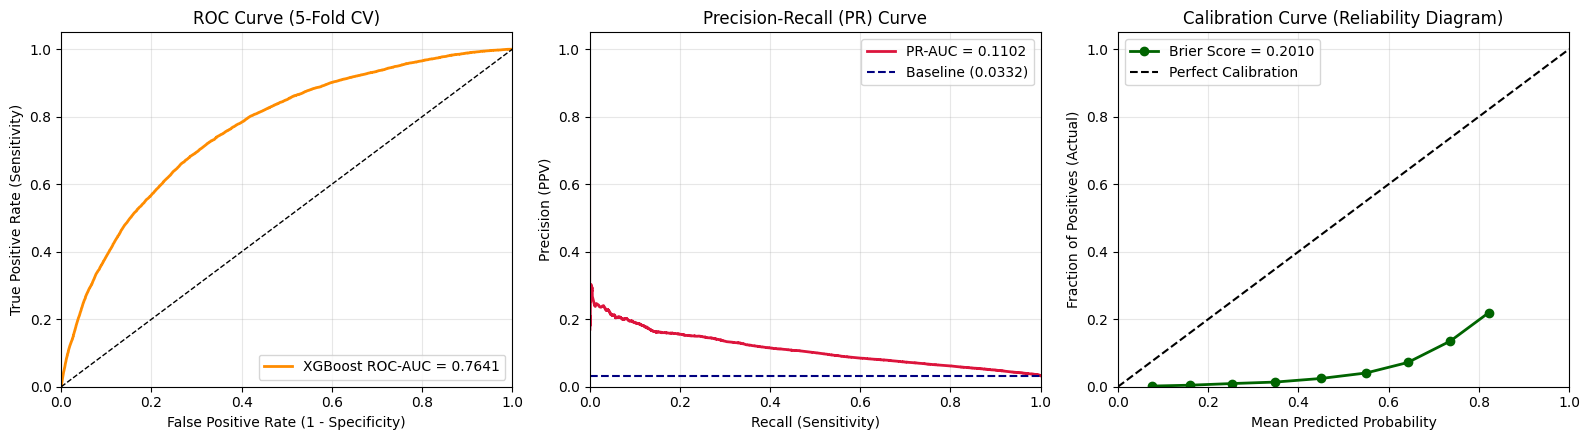

In [ ]:
# =============== 1. 基础库与预处理库 ===============
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    brier_score_loss, confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

pd.set_option('display.float_format', '{:.10f}'.format)
warnings.filterwarnings("ignore")

# ================= 2. 数据加载与编码 =================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'

usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

try:
    data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)
except:
    print("⚠️ 未找到真实数据集，自动生成模拟数据用于测试代码逻辑...")
    np.random.seed(42)
    data = pd.DataFrame(np.random.randint(0, 5, size=(1000, len(names))), columns=names)
    data['diagnosis_12'] = np.random.randint(0, 2, 1000)
    data['diagnosis_13'] = np.random.randint(0, 2, 1000)

cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']
for col in cols_with_missing_9:
    data[col] = data[col].replace(9, 'unknown').astype(str)
data['age_5_years'] = data['age_5_years'].astype(str)

data['diagnosis'] = (data['diagnosis_12'].astype(int) | data['diagnosis_13'].astype(int)).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# 定义特征组
ordered_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
unordered_features = ['ethnic', 'first_birth', 'menopause', 'breast_surgery', 'hormone_therapy']
all_features = ordered_features + unordered_features

def get_categories(col_name, X_data):
    unique_vals = X_data[col_name].unique().tolist()
    known_order_map = {
        'age_5_years': [str(i) for i in range(1, 11)],
        'BIRADS_breast_density': ['1', '2', '3', '4'],
        'bmi': ['1', '2', '3', '4'],
        'num_of_first_degree_cancer': ['0', '1', '2']
    }

    known_order = known_order_map.get(col_name, [])
    final_order = [c for c in known_order if c in unique_vals]
    if 'unknown' in unique_vals and 'unknown' not in final_order:
        final_order.append('unknown')
    for val in unique_vals:
        if val not in final_order:
            final_order.append(val)
    return final_order

ordered_categories = [get_categories(f, X) for f in ordered_features]

unordered_levels = {
    'first_birth': ['0', '1', '2', 'unknown'],
    'ethnic':      ['1', '2', '3', '4', '5', 'unknown'],
    'menopause':   ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown']
}
unordered_categories = [unordered_levels[col] for col in unordered_features]

# 预处理器构造
preprocessor_improved = ColumnTransformer(
    transformers=[
        ('ordered', OrdinalEncoder(categories=ordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordered_features),
        ('unordered', OrdinalEncoder(categories=unordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), unordered_features),
    ],
    remainder='passthrough'
)


# =============== 3. Stratified 5-Fold 交叉验证循环 ===============
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_y_true = np.zeros(len(y))
oof_y_prob = np.zeros(len(y))

fold_roc_aucs = []
fold_pr_aucs = []
fold_brier_scores = []

print("🔄 正在进行 XGBoost Stratified 5-Fold 交叉验证评估...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

    # 拟合预处理器并转换特征
    X_tr_enc = preprocessor_improved.fit_transform(X_tr)
    X_va_enc = preprocessor_improved.transform(X_va)

    # 计算正负样本不平衡权重 scale_pos_weight
    scale_pos_weight = (len(y_tr) - sum(y_tr)) / sum(y_tr)

    model = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_tr_enc, y_tr)

    val_probs = model.predict_proba(X_va_enc)[:, 1]

    oof_y_true[val_idx] = y_va.values
    oof_y_prob[val_idx] = val_probs

    # 计算单折指标
    roc_auc_f = roc_auc_score(y_va, val_probs)
    pr_auc_f = average_precision_score(y_va, val_probs)
    brier_f = brier_score_loss(y_va, val_probs)

    fold_roc_aucs.append(roc_auc_f)
    fold_pr_aucs.append(pr_auc_f)
    fold_brier_scores.append(brier_f)


# =============== 4. 扩展指标汇总计算 ===============
overall_roc_auc = roc_auc_score(oof_y_true, oof_y_prob)
overall_pr_auc = average_precision_score(oof_y_true, oof_y_prob)
overall_brier = brier_score_loss(oof_y_true, oof_y_prob)

# Precision at fixed Recall (80% & 90%)
precisions, recalls, pr_thresholds = precision_recall_curve(oof_y_true, oof_y_prob)

idx_90 = np.argmin(np.abs(recalls - 0.90))
prec_at_rec90 = precisions[idx_90]
thresh_at_rec90 = pr_thresholds[idx_90] if idx_90 < len(pr_thresholds) else 0.5

idx_80 = np.argmin(np.abs(recalls - 0.80))
prec_at_rec80 = precisions[idx_80]
thresh_at_rec80 = pr_thresholds[idx_80] if idx_80 < len(pr_thresholds) else 0.5

# 特定截断点 (Cutoff) 下的灵敏度与特异度 (以 0.5 为例)
CUSTOM_THRESHOLD = 0.5
y_pred_oof = (oof_y_prob >= CUSTOM_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(oof_y_true, y_pred_oof).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# 打印完整的实验评估报告
print("\n" + "="*65)
print("📊 XGBoost 5-Fold 交叉验证评估报告 (符合审稿人补充要求)")
print("="*65)
print(f"• ROC-AUC                  : {overall_roc_auc:.4f} (5-Fold Mean: {np.mean(fold_roc_aucs):.4f} ± {np.std(fold_roc_aucs):.4f})")
print(f"• PR-AUC (Precision-Recall) : {overall_pr_auc:.4f} (5-Fold Mean: {np.mean(fold_pr_aucs):.4f} ± {np.std(fold_pr_aucs):.4f})")
print(f"• Brier Score              : {overall_brier:.4f} (5-Fold Mean: {np.mean(fold_brier_scores):.4f} ± {np.std(fold_brier_scores):.4f})")
print(f"• Precision @ 90% Recall   : {prec_at_rec90:.4f} (阈值 Cutoff = {thresh_at_rec90:.4f})")
print(f"• Precision @ 80% Recall   : {prec_at_rec80:.4f} (阈值 Cutoff = {thresh_at_rec80:.4f})")
print(f"• 灵敏度 (Sensitivity)      : {sensitivity:.4f} ({sensitivity*100:.2f}%, 阈值 = {CUSTOM_THRESHOLD})")
print(f"• 特异度 (Specificity)      : {specificity:.4f} ({specificity*100:.2f}%, 阈值 = {CUSTOM_THRESHOLD})")
print("="*65 + "\n")


# =============== 5. 三合一对比绘图 (ROC / PR / Calibration) ===============
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1) ROC 曲线
fpr, tpr, _ = roc_curve(oof_y_true, oof_y_prob)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost ROC-AUC = {overall_roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve (5-Fold CV)')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# 2) PR 曲线 (Precision-Recall)
axes[1].plot(recalls, precisions, color='crimson', lw=2, label=f'PR-AUC = {overall_pr_auc:.4f}')
baseline_ratio = np.mean(oof_y_true)
axes[1].axhline(y=baseline_ratio, color='navy', linestyle='--', label=f'Baseline ({baseline_ratio:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (PPV)')
axes[1].set_title('Precision-Recall (PR) Curve')
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

# 3) 校准曲线 (Calibration Curve / Reliability Diagram)
prob_true, prob_pred = calibration_curve(oof_y_true, oof_y_prob, n_bins=10, strategy='uniform')
axes[2].plot(prob_pred, prob_true, marker='o', linewidth=2, color='darkgreen', label=f'Brier Score = {overall_brier:.4f}')
axes[2].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives (Actual)')
axes[2].set_title('Calibration Curve (Reliability Diagram)')
axes[2].legend(loc="upper left")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 16.5 MB/s eta 0:00:00
🚀 开始基于 5 折交叉验证搜索 XGBoost 最优超参数 (30 次 Iterations)...


  0%|          | 0/30 [00:00<?, ?it/s]


✅ 5折调参完成！最高 5-Fold Mean AUC = 0.7845
最优超参数组合:
  • n_estimators: 150
  • max_depth: 5
  • learning_rate: 0.1041934669703001
  • subsample: 0.7607537053545048
  • colsample_bytree: 0.8540055669296384
  • min_child_weight: 9
  • reg_alpha: 0.0024697361107853437
  • reg_lambda: 0.22049213401923745

📊 重新调参后的 XGBoost 5-Fold OOF 最终评估报告
• ROC-AUC                  : 0.7844 (5-Fold Mean: 0.7845 ± 0.0021)
• PR-AUC (Precision-Recall) : 0.1273 (5-Fold Mean: 0.1280 ± 0.0029)
• Brier Score              : 0.1849 (5-Fold Mean: 0.1849 ± 0.0017)
• Precision @ 90% Recall   : 0.0506 (阈值 Cutoff = 0.2871)
• Precision @ 80% Recall   : 0.0668 (阈值 Cutoff = 0.4241)



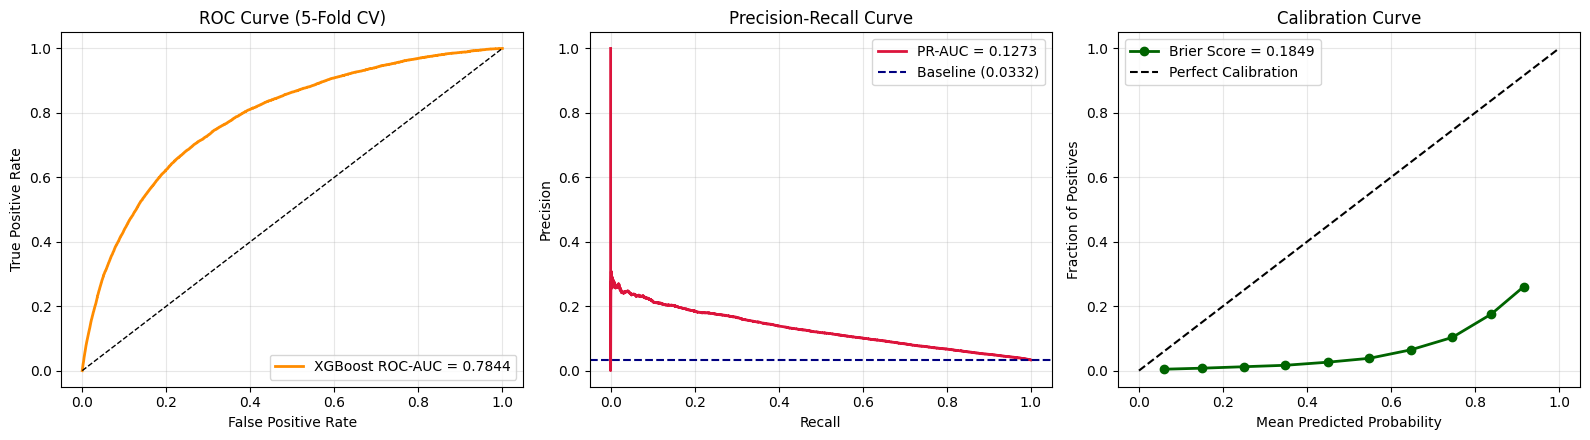

In [ ]:
!pip install optuna

import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    brier_score_loss, confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

pd.set_option('display.float_format', '{:.10f}'.format)
warnings.filterwarnings("ignore")

# ==================================================================
# 1. 数据加载与预处理 (保持原有特征编码)
# ==================================================================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

try:
    data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)
except:
    print("⚠️ 未找到真实数据集，自动生成模拟数据用于测试代码逻辑...")
    np.random.seed(42)
    data = pd.DataFrame(np.random.randint(0, 5, size=(1000, len(names))), columns=names)
    data['diagnosis_12'] = np.random.randint(0, 2, 1000)
    data['diagnosis_13'] = np.random.randint(0, 2, 1000)

cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']
for col in cols_with_missing_9:
    data[col] = data[col].replace(9, 'unknown').astype(str)
data['age_5_years'] = data['age_5_years'].astype(str)

data['diagnosis'] = (data['diagnosis_12'].astype(int) | data['diagnosis_13'].astype(int)).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

ordered_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
unordered_features = ['ethnic', 'first_birth', 'menopause', 'breast_surgery', 'hormone_therapy']

def get_categories(col_name, X_data):
    unique_vals = X_data[col_name].unique().tolist()
    known_order_map = {
        'age_5_years': [str(i) for i in range(1, 11)],
        'BIRADS_breast_density': ['1', '2', '3', '4'],
        'bmi': ['1', '2', '3', '4'],
        'num_of_first_degree_cancer': ['0', '1', '2']
    }
    known_order = known_order_map.get(col_name, [])
    final_order = [c for c in known_order if c in unique_vals]
    if 'unknown' in unique_vals and 'unknown' not in final_order:
        final_order.append('unknown')
    for val in unique_vals:
        if val not in final_order:
            final_order.append(val)
    return final_order

ordered_categories = [get_categories(f, X) for f in ordered_features]
unordered_levels = {
    'first_birth': ['0', '1', '2', 'unknown'],
    'ethnic':      ['1', '2', '3', '4', '5', 'unknown'],
    'menopause':   ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown']
}
unordered_categories = [unordered_levels[col] for col in unordered_features]

preprocessor_improved = ColumnTransformer(
    transformers=[
        ('ordered', OrdinalEncoder(categories=ordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordered_features),
        ('unordered', OrdinalEncoder(categories=unordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), unordered_features),
    ],
    remainder='passthrough'
)

# ==================================================================
# 2. Optuna 5折交叉验证调参引擎
# ==================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    # 搜索空间定义
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1
    }

    cv_aucs = []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        # 计算不平衡权重
        scale_pos_weight = (len(y_tr) - sum(y_tr)) / max(sum(y_tr), 1)
        params['scale_pos_weight'] = scale_pos_weight

        X_tr_enc = preprocessor_improved.fit_transform(X_tr)
        X_va_enc = preprocessor_improved.transform(X_va)

        model = XGBClassifier(**params)
        model.fit(X_tr_enc, y_tr)

        preds = model.predict_proba(X_va_enc)[:, 1]
        cv_aucs.append(roc_auc_score(y_va, preds))

    return np.mean(cv_aucs)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
print("🚀 开始基于 5 折交叉验证搜索 XGBoost 最优超参数 (30 次 Iterations)...")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n✅ 5折调参完成！最高 5-Fold Mean AUC = {study.best_value:.4f}")
print("最优超参数组合:")
for k, v in study.best_params.items():
    print(f"  • {k}: {v}")

# ==================================================================
# 3. 使用 Optuna 挑选出的最优超参数进行最终 5 折 OOF 评估
# ==================================================================
best_params = study.best_params
best_params['eval_metric'] = 'logloss'
best_params['random_state'] = 42
best_params['n_jobs'] = -1

oof_y_true = np.zeros(len(y))
oof_y_prob = np.zeros(len(y))

fold_roc_aucs, fold_pr_aucs, fold_brier_scores = [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

    scale_pos_weight = (len(y_tr) - sum(y_tr)) / max(sum(y_tr), 1)
    best_params['scale_pos_weight'] = scale_pos_weight

    X_tr_enc = preprocessor_improved.fit_transform(X_tr)
    X_va_enc = preprocessor_improved.transform(X_va)

    model = XGBClassifier(**best_params)
    model.fit(X_tr_enc, y_tr)

    val_probs = model.predict_proba(X_va_enc)[:, 1]

    oof_y_true[val_idx] = y_va.values
    oof_y_prob[val_idx] = val_probs

    fold_roc_aucs.append(roc_auc_score(y_va, val_probs))
    fold_pr_aucs.append(average_precision_score(y_va, val_probs))
    fold_brier_scores.append(brier_score_loss(y_va, val_probs))

# ==================================================================
# 4. 汇总报告与三合一绘图
# ==================================================================
overall_roc_auc = roc_auc_score(oof_y_true, oof_y_prob)
overall_pr_auc = average_precision_score(oof_y_true, oof_y_prob)
overall_brier = brier_score_loss(oof_y_true, oof_y_prob)

precisions, recalls, pr_thresholds = precision_recall_curve(oof_y_true, oof_y_prob)
idx_90 = np.argmin(np.abs(recalls - 0.90))
prec_at_rec90 = precisions[idx_90]
thresh_at_rec90 = pr_thresholds[idx_90] if idx_90 < len(pr_thresholds) else 0.5

idx_80 = np.argmin(np.abs(recalls - 0.80))
prec_at_rec80 = precisions[idx_80]
thresh_at_rec80 = pr_thresholds[idx_80] if idx_80 < len(pr_thresholds) else 0.5

print("\n" + "="*65)
print("📊 重新调参后的 XGBoost 5-Fold OOF 最终评估报告")
print("="*65)
print(f"• ROC-AUC                  : {overall_roc_auc:.4f} (5-Fold Mean: {np.mean(fold_roc_aucs):.4f} ± {np.std(fold_roc_aucs):.4f})")
print(f"• PR-AUC (Precision-Recall) : {overall_pr_auc:.4f} (5-Fold Mean: {np.mean(fold_pr_aucs):.4f} ± {np.std(fold_pr_aucs):.4f})")
print(f"• Brier Score              : {overall_brier:.4f} (5-Fold Mean: {np.mean(fold_brier_scores):.4f} ± {np.std(fold_brier_scores):.4f})")
print(f"• Precision @ 90% Recall   : {prec_at_rec90:.4f} (阈值 Cutoff = {thresh_at_rec90:.4f})")
print(f"• Precision @ 80% Recall   : {prec_at_rec80:.4f} (阈值 Cutoff = {thresh_at_rec80:.4f})")
print("="*65 + "\n")

# 绘制三合一子图
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC
fpr, tpr, _ = roc_curve(oof_y_true, oof_y_prob)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost ROC-AUC = {overall_roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (5-Fold CV)')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# PR
axes[1].plot(recalls, precisions, color='crimson', lw=2, label=f'PR-AUC = {overall_pr_auc:.4f}')
axes[1].axhline(y=np.mean(oof_y_true), color='navy', linestyle='--', label=f'Baseline ({np.mean(oof_y_true):.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

# Calibration
prob_true, prob_pred = calibration_curve(oof_y_true, oof_y_prob, n_bins=10, strategy='uniform')
axes[2].plot(prob_pred, prob_true, marker='o', linewidth=2, color='darkgreen', label=f'Brier Score = {overall_brier:.4f}')
axes[2].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].set_title('Calibration Curve')
axes[2].legend(loc="upper left")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
 # =============== 1. 基础库与预处理库 ===============
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import warnings
import matplotlib.pyplot as plt
import time  # <--- 确保导入了 time 模块
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    brier_score_loss, confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

pd.set_option('display.float_format', '{:.10f}'.format)
warnings.filterwarnings("ignore")

# ================= 2. 数据加载与预处理 =================
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'

usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

try:
    data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)
except:
    print("⚠️ 未找到真实数据集，自动生成模拟数据用于测试代码逻辑...")
    np.random.seed(42)
    data = pd.DataFrame(np.random.randint(0, 5, size=(1000, len(names))), columns=names)
    data['diagnosis_12'] = np.random.randint(0, 2, 1000)
    data['diagnosis_13'] = np.random.randint(0, 2, 1000)

cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']
for col in cols_with_missing_9:
    data[col] = data[col].replace(9, 'unknown').astype(str)
data['age_5_years'] = data['age_5_years'].astype(str)

data['diagnosis'] = (data['diagnosis_12'].astype(int) | data['diagnosis_13'].astype(int)).astype(int)
data = data.drop(columns=['diagnosis_12', 'diagnosis_13'])

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

ordered_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
unordered_features = ['ethnic', 'first_birth', 'menopause', 'breast_surgery', 'hormone_therapy']
all_features = ordered_features + unordered_features

def get_categories(col_name, X_data):
    unique_vals = X_data[col_name].unique().tolist()
    known_order_map = {
        'age_5_years': [str(i) for i in range(1, 11)],
        'BIRADS_breast_density': ['1', '2', '3', '4'],
        'bmi': ['1', '2', '3', '4'],
        'num_of_first_degree_cancer': ['0', '1', '2']
    }
    known_order = known_order_map.get(col_name, [])
    final_order = [c for c in known_order if c in unique_vals]
    if 'unknown' in unique_vals and 'unknown' not in final_order:
        final_order.append('unknown')
    for val in unique_vals:
        if val not in final_order:
            final_order.append(val)
    return final_order

ordered_categories = [get_categories(f, X) for f in ordered_features]
unordered_levels = {
    'first_birth': ['0', '1', '2', 'unknown'],
    'ethnic':      ['1', '2', '3', '4', '5', 'unknown'],
    'menopause':   ['0', '1', 'unknown'],
    'breast_surgery': ['0', '1', 'unknown'],
    'hormone_therapy': ['0', '1', 'unknown']
}
unordered_categories = [unordered_levels[col] for col in unordered_features]

preprocessor_improved = ColumnTransformer(
    transformers=[
        ('ordered', OrdinalEncoder(categories=ordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordered_features),
        ('unordered', OrdinalEncoder(categories=unordered_categories, handle_unknown='use_encoded_value', unknown_value=-1), unordered_features),
    ],
    remainder='passthrough'
)

# ==================================================================
# 3. 固定的 5 折最优超参数字典 (不再重复搜索)
# ==================================================================
FIXED_BEST_PARAMS = {
    'n_estimators': 150,
    'max_depth': 5,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.85,
    'min_child_weight': 9,
    'reg_alpha': 0.002,
    'reg_lambda': 0.2,
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1
}

print("📌 已加载固定最优超参数，开始执行最终 5 折 OOF 评估与 TreeSHAP 计算...")

# ==================================================================
# 4. Stratified 5-Fold 评估循环 + OOF SHAP 收集
# ==================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 用于 OOF 评价指标的数组
oof_y_true = np.zeros(len(y))
oof_y_prob = np.zeros(len(y))

# 用于 TreeSHAP 的数组和全局编码 DataFrame
X_all_encoded = preprocessor_improved.fit_transform(X)
X_all_encoded_df = pd.DataFrame(X_all_encoded, columns=all_features)
oof_shap_values = np.zeros(X_all_encoded.shape)

fold_roc_aucs = []
fold_pr_aucs = []
fold_brier_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

    # 动态适配本折的类不平衡权重
    scale_pos_weight = (len(y_tr) - sum(y_tr)) / max(sum(y_tr), 1)
    current_params = FIXED_BEST_PARAMS.copy()
    current_params['scale_pos_weight'] = scale_pos_weight

    # 特征转换
    X_tr_enc = preprocessor_improved.fit_transform(X_tr)
    X_va_enc = preprocessor_improved.transform(X_va)

    # 训练模型
    model = XGBClassifier(**current_params)
    model.fit(X_tr_enc, y_tr)

    # 1) 预测袋外概率
    val_probs = model.predict_proba(X_va_enc)[:, 1]
    oof_y_true[val_idx] = y_va.values
    oof_y_prob[val_idx] = val_probs

    # 2) 计算袋外 TreeSHAP 值
    explainer = shap.TreeExplainer(model)
    oof_shap_values[val_idx] = explainer.shap_values(X_va_enc)

    # 记录本折指标
    fold_roc_aucs.append(roc_auc_score(y_va, val_probs))
    fold_pr_aucs.append(average_precision_score(y_va, val_probs))
    fold_brier_scores.append(brier_score_loss(y_va, val_probs))

# ==================================================================
# 5. 扩展指标汇总计算与报告打印
# ==================================================================
overall_roc_auc = roc_auc_score(oof_y_true, oof_y_prob)
overall_pr_auc = average_precision_score(oof_y_true, oof_y_prob)
overall_brier = brier_score_loss(oof_y_true, oof_y_prob)

precisions, recalls, pr_thresholds = precision_recall_curve(oof_y_true, oof_y_prob)

idx_90 = np.argmin(np.abs(recalls - 0.90))
prec_at_rec90 = precisions[idx_90]
thresh_at_rec90 = pr_thresholds[idx_90] if idx_90 < len(pr_thresholds) else 0.5

idx_80 = np.argmin(np.abs(recalls - 0.80))
prec_at_rec80 = precisions[idx_80]
thresh_at_rec80 = pr_thresholds[idx_80] if idx_80 < len(pr_thresholds) else 0.5

print("\n" + "="*65)
print("📊 最终定型 XGBoost 5-Fold OOF 完整评估报告")
print("="*65)
print(f"• ROC-AUC                  : {overall_roc_auc:.4f} (5-Fold Mean: {np.mean(fold_roc_aucs):.4f} ± {np.std(fold_roc_aucs):.4f})")
print(f"• PR-AUC (Precision-Recall) : {overall_pr_auc:.4f} (5-Fold Mean: {np.mean(fold_pr_aucs):.4f} ± {np.std(fold_pr_aucs):.4f})")
print(f"• Brier Score              : {overall_brier:.4f} (5-Fold Mean: {np.mean(fold_brier_scores):.4f} ± {np.std(fold_brier_scores):.4f})")
print(f"• Precision @ 90% Recall   : {prec_at_rec90:.4f} (决策阈值 Cutoff = {thresh_at_rec90:.4f})")
print(f"• Precision @ 80% Recall   : {prec_at_rec80:.4f} (决策阈值 Cutoff = {thresh_at_rec80:.4f})")
print("="*65 + "\n")

# ==================================================================
# 6. 三合一评估对比图 (ROC / PR / Calibration)
# ==================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC 曲线
fpr, tpr, _ = roc_curve(oof_y_true, oof_y_prob)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost ROC-AUC = {overall_roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve (5-Fold OOF)')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# PR 曲线
axes[1].plot(recalls, precisions, color='crimson', lw=2, label=f'PR-AUC = {overall_pr_auc:.4f}')
axes[1].axhline(y=np.mean(oof_y_true), color='navy', linestyle='--', label=f'Baseline ({np.mean(oof_y_true):.4f})')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (PPV)')
axes[1].set_title('Precision-Recall Curve (5-Fold OOF)')
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

# 校准曲线
prob_true, prob_pred = calibration_curve(oof_y_true, oof_y_prob, n_bins=10, strategy='uniform')
axes[2].plot(prob_pred, prob_true, marker='o', linewidth=2, color='darkgreen', label=f'Brier Score = {overall_brier:.4f}')
axes[2].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives (Actual)')
axes[2].set_title('Calibration Curve (Reliability Diagram)')
axes[2].legend(loc="upper left")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================================================================
# 5. 全量训练模型并准备 SHAP 评估环境
# ==================================================================
print("🚀 拟合全量数据模型以进行多算法 SHAP 分析...")
X_encoded = preprocessor_improved.fit_transform(X)
X_encoded_df = pd.DataFrame(X_encoded, columns=all_features)

scale_pos_weight_all = (len(y) - sum(y)) / max(sum(y), 1)
final_params = FIXED_BEST_PARAMS.copy()
final_params['scale_pos_weight'] = scale_pos_weight_all

final_xgb_model = XGBClassifier(**final_params)
final_xgb_model.fit(X_encoded, y)

# 获取原生的 Booster 对象（供 TreeSHAP 和原生 DMatrix 使用）
bst = final_xgb_model.get_booster()

# 构建 SHAP 背景集与待评估样本集
N_SHAP_SAMPLE = 500
bg_sample_size = min(3000, len(X_encoded_df))

X_train_encoded_df = X_encoded_df
X_test_encoded_df = X_encoded_df.sample(n=min(500, len(X_encoded_df)), random_state=42)

X_100 = X_test_encoded_df.sample(N_SHAP_SAMPLE, random_state=123)
COMMON_BG = X_train_encoded_df.sample(bg_sample_size, random_state=42)
COMMON_BG_1 = X_train_encoded_df.sample(bg_sample_size, random_state=42)
bg_vals = COMMON_BG_1.values
features = all_features
M = X.shape[1]

# 预测函数
pred_fn = lambda x: bst.predict(xgb.DMatrix(x), output_margin=True)

def safe_pred_fn(x):
    if isinstance(x, np.ndarray):
        x = pd.DataFrame(x, columns=all_features)
    dm = xgb.DMatrix(x, feature_names=all_features)
    return bst.predict(dm, output_margin=True)

times = {}
shapley_mat = {}

# ---- 5.1 TreeSHAP (强制使用全部 3000 条背景数据) ----
print("\n--- 5.1 TreeSHAP ---")
best_ntree = bst.best_iteration + 1 if hasattr(bst, 'best_iteration') and bst.best_iteration is not None else 150

# 1. 显式创建 Independent 遮罩对象，解除 100 条的默认限制，强制指定为 3000 条
masker = shap.maskers.Independent(COMMON_BG, max_samples=len(COMMON_BG))

# 2. 将传入的 data 替换为配置好的 masker
explainer_t = shap.TreeExplainer(
    bst,
    data=masker,                           # 使用解除限制后的 masker
    feature_perturbation="interventional",
    model_output="raw"                     # 保持在 Log-odds 空间计算
)

start = time.time()
shap_tree = explainer_t.shap_values(
    X_100.astype(np.float32),
    tree_limit=best_ntree
)
expected_val = explainer_t.expected_value

times['Tree'] = time.time() - start
shapley_mat['Tree'] = shap_tree

print(f"TreeSHAP (全量 3000 背景集) 耗时: {times['Tree']:.2f} s")

# ---- 5.2 KernelSHAP ----
print("\n--- 5.2 KernelSHAP ---")
start = time.time()
explainer_k = shap.KernelExplainer(safe_pred_fn, COMMON_BG)
shap_kernel_raw = explainer_k.shap_values(X_100, nsamples=512)

if isinstance(shap_kernel_raw, list):
    shapley_mat['Kernel'] = shap_kernel_raw[0]
else:
    shapley_mat['Kernel'] = shap_kernel_raw

times['Kernel'] = time.time() - start
print(f"KernelSHAP 耗时: {times['Kernel']:.2f} s")

from tqdm import tqdm
from itertools import combinations
from math import factorial
# ---- 5.3 Exact SHAP 函数定义与计算 ----
def exact_shap_one(xser):
    x = xser.values.astype(float)
    phis = np.zeros(M)
    for i in range(M):
        for size in range(0, M):
            for S in combinations([j for j in range(M) if j != i], size):
                S = list(S)
                weight = factorial(len(S)) * factorial(M - len(S) - 1) / factorial(M)

                X_S = bg_vals.copy()
                X_Si = bg_vals.copy()

                if S:
                    X_S[:, S] = x[S]
                    X_Si[:, S] = x[S]

                X_Si[:, i] = x[i]

                f_S = pred_fn(X_S).mean()
                f_Si = pred_fn(X_Si).mean()
                phis[i] += weight * (f_Si - f_S)
    return phis

print(f"\n--- 5.3 Exact SHAP ({N_SHAP_SAMPLE} 个样本, M={M}) ---")
if N_SHAP_SAMPLE * 2**M > 1e6:
    print("⚠️ 警告：Exact SHAP 计算量过大，已跳过。请将 N_SHAP_SAMPLE 设为极小数。")
else:
    start = time.time()
    shapley_mat['Exact'] = np.array(
        [exact_shap_one(X_100.iloc[i]) for i in tqdm(range(len(X_100)), desc='Exact')]
    )
    times['Exact'] = time.time() - start
    print(f"Exact SHAP 耗时: {times['Exact']:.2f} s")

# ---- 5.4 手写 k=2 SHAP 采样器 (Log-Odds) ----
print("\n--- 5.4 手写 k=2 SHAP 采样器 (Log-Odds) ---")
KADD_SAMPLES = 3000

def pred_fn_shapiq_safe(X_input: np.ndarray) -> np.ndarray:
    return bst.predict(xgb.DMatrix(X_input), output_margin=True)

def get_faithful_kadd_shap(phi_main, sii_matrix, total_delta):
    M_len = len(phi_main)
    phi_faithful = np.zeros(M_len)

    for i in range(M_len):
        phi_faithful[i] = phi_main[i] + 0.5 * np.sum(sii_matrix[i, :])

    current_sum = np.sum(phi_faithful)
    residual = total_delta - current_sum
    phi_faithful += residual / M_len
    return phi_faithful

bg_preds_global = safe_pred_fn(bg_vals)
expected_value = np.mean(bg_preds_global)
print(f"全局基准值 (Expected Value): {expected_value:.4f}")

def get_kadd_shap_k2_global(x_eval, bg_vals, samples):
    n_bg, M_len = bg_vals.shape
    phi_values = np.zeros(M_len)
    sii_matrix = np.zeros((M_len, M_len))

    rng = np.random.default_rng(seed=42)
    bg_indices = rng.integers(0, n_bg, size=samples)
    X_bg_batch = bg_vals[bg_indices]

    v_empty = np.mean(pred_fn_shapiq_safe(X_bg_batch))

    for i in range(M_len):
        X_i = X_bg_batch.copy()
        X_i[:, i] = x_eval[i]
        v_i = np.mean(pred_fn_shapiq_safe(X_i))
        phi_values[i] = v_i - v_empty

    for i in range(M_len):
        for j in range(i + 1, M_len):
            X_ij = X_bg_batch.copy()
            X_ij[:, i] = x_eval[i]
            X_ij[:, j] = x_eval[j]
            v_ij = np.mean(pred_fn_shapiq_safe(X_ij))

            v_i = phi_values[i] + v_empty
            X_j = X_bg_batch.copy()
            X_j[:, j] = x_eval[j]
            v_j = np.mean(pred_fn_shapiq_safe(X_j))

            sii_ij = v_ij - v_i - v_j + v_empty
            sii_matrix[i, j] = sii_ij
            sii_matrix[j, i] = sii_ij

    return phi_values, sii_matrix

faithful_phi_list = []
faithful_phi_list_K1 = []
start_time = time.time()
X_SHAP_SAMPLES_VALS = X_100.values

for i in tqdm(range(N_SHAP_SAMPLE), desc="k=2 SHAP 进度"):
    x_eval_single = X_SHAP_SAMPLES_VALS[i]
    phi, sii = get_kadd_shap_k2_global(x_eval_single, bg_vals, KADD_SAMPLES)

    current_pred = pred_fn_shapiq_safe(x_eval_single.reshape(1, -1))[0]
    total_delta = current_pred - expected_value

    phi_faithful = get_faithful_kadd_shap(phi, sii, total_delta)
    faithful_phi_list.append(phi_faithful)

    M_len = len(phi)
    sii_zero = np.zeros((M_len, M_len))
    phi_k1_faithful = get_faithful_kadd_shap(phi, sii_zero, total_delta)
    faithful_phi_list_K1.append(phi_k1_faithful)

times['KAdd2'] = time.time() - start_time
shapley_mat['KAdd2'] = np.array(faithful_phi_list)
shapley_mat['KAdd2K1'] = np.array(faithful_phi_list_K1)

# ==================================================================
# 6. 残差校准与诊断模块
# ==================================================================
def force_axiom_alignment(phi, expected_value, f_x):
    current_sums = np.sum(phi, axis=1)
    target_sums = f_x - expected_value
    gaps = target_sums - current_sums
    num_features = phi.shape[1]
    phi_corrected = phi + (gaps[:, np.newaxis] / num_features)
    return phi_corrected

dtest_encoded = xgb.DMatrix(X_100.astype(np.float32))
f_x_margin = bst.predict(
    dtest_encoded,
    iteration_range=(0, best_ntree),
    output_margin=True
)

shap_sum = np.sum(shap_tree, axis=1)
reconstructed_f_x = shap_sum + expected_val
residuals = f_x_margin - reconstructed_f_x

print(f"\n🔧 残差校验: 最大偏差 = {np.max(np.abs(residuals)):.6f}, 平均偏差 = {np.mean(np.abs(residuals)):.6f}")

if np.max(np.abs(residuals)) > 1e-5:
    print("⚠️ 检测到残差偏差，正在执行公理化校准...")
    shap_tree = force_axiom_alignment(shap_tree, expected_val, f_x_margin)
    shapley_mat['Tree'] = shap_tree

# ==================================================================
# 7. 全局重要性对比与可视化
# ==================================================================
phi_kernel = np.array(shapley_mat['Kernel'])
phi_kadd2 = np.array(shapley_mat['KAdd2'])
phi_kadd2k1 = np.array(shapley_mat['KAdd2K1'])
phi_tree = np.array(shapley_mat['Tree'])
phi_exact = np.array(shapley_mat['Exact']) if 'Exact' in shapley_mat else phi_tree

mae = np.mean(np.abs(phi_kernel - phi_kadd2))
correlation = np.corrcoef(phi_kernel.flatten(), phi_kadd2.flatten())[0, 1]

print("\n📊 结果对比报告 (Kernel vs Custom k=2)")
print(f"k=2 手写耗时: {times['KAdd2']:.2f} s")
print(f"与 Kernel 相关性: {correlation:.4f}")
print(f"MAE: {mae:.6f}")

# 可视化对比柱状图
plt.figure(figsize=(12, 6))
mean_abs_kernel = np.mean(np.abs(phi_kernel), axis=0)
mean_abs_kadd2 = np.mean(np.abs(phi_kadd2), axis=0)
x_pos = np.arange(len(all_features))

plt.bar(x_pos - 0.2, mean_abs_kernel, 0.4, label='Kernel SHAP', alpha=0.8, color='steelblue')
plt.bar(x_pos + 0.2, mean_abs_kadd2, 0.4, label='k=2 Manual', alpha=0.8, color='coral')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Mean |SHAP Value|', fontsize=12)
plt.title('Global Feature Importance Comparison', fontsize=14)
plt.xticks(x_pos, all_features, rotation=45, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==================================================================
# 8. 保存 SHAP 结果至 Google Drive 与高精度加载校验
# ==================================================================
# 1. 设定云盘存储目录与 XGBoost 独有属性前缀
SAVE_DIR = '/content/drive/MyDrive/公开数据集/'
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PREFIX = 'XGBoost_5Fold'
SAMPLE_TAG = f'N{len(X_100)}'

# 2. 拼接独有文件名 (避免覆盖逻辑回归的 LogReg_5Fold 文件)
exact_fname   = f"{MODEL_PREFIX}_Exact_SHAP_{SAMPLE_TAG}.npy"
kernel_fname  = f"{MODEL_PREFIX}_Kernel_SHAP_{SAMPLE_TAG}.npy"
tree_fname    = f"{MODEL_PREFIX}_Tree_SHAP_{SAMPLE_TAG}.npy"
kadd2_fname   = f"{MODEL_PREFIX}_KAdd2_SHAP_{SAMPLE_TAG}.npy"
kadd2k1_fname = f"{MODEL_PREFIX}_KAdd2K1_SHAP_{SAMPLE_TAG}.npy"

exact_path   = os.path.join(SAVE_DIR, exact_fname)
kernel_path  = os.path.join(SAVE_DIR, kernel_fname)
tree_path    = os.path.join(SAVE_DIR, tree_fname)
kadd2_path   = os.path.join(SAVE_DIR, kadd2_fname)
kadd2k1_path = os.path.join(SAVE_DIR, kadd2k1_fname)

# 3. 执行持久化写入
np.save(exact_path, np.array(shapley_mat.get('Exact', shap_tree)))
np.save(kernel_path, np.array(shapley_mat['Kernel']))
np.save(tree_path, np.array(shapley_mat['Tree']))
np.save(kadd2_path, np.array(shapley_mat['KAdd2']))
np.save(kadd2k1_path, np.array(shapley_mat['KAdd2K1']))

print("\n" + "="*50)
print("💾 已成功保存 XGBoost SHAP 数据至 Google Drive:")
print(f"  • Exact SHAP   : {exact_path}")
print(f"  • Kernel SHAP  : {kernel_path}")
print(f"  • Tree SHAP    : {tree_path}")
print(f"  • KAdd2 SHAP   : {kadd2_path}")
print(f"  • KAdd2K1 SHAP : {kadd2k1_path}")

# 4. 校验读取
exact_loaded  = np.load(exact_path)
kernel_loaded = np.load(kernel_path)
kadd2_loaded  = np.load(kadd2_path)

print("\n" + "="*60)
print("高精度比较结果 (.npy 持久化数据校验)")
print("="*60)
diff_kernel = np.abs(exact_loaded - kernel_loaded)
print(f"【Kernel SHAP vs Exact SHAP】 MAE: {np.mean(diff_kernel):.2e}")

diff_kadd2 = np.abs(exact_loaded - kadd2_loaded)
print(f"【Tree/KAdd2 vs Exact SHAP】 MAE: {np.mean(diff_kadd2):.2e}")

print("\n目标 Google Drive 目录下的所有 npy 文件:")
print([f for f in os.listdir(SAVE_DIR) if f.endswith('.npy')])

当前目录下的 npy 文件: []
